# NLP 2025
# Lab 2: Word Vectors and Information Retrieval

During the first few weeks, we discussed various ways to represent text 📝. One key question was: What should be the basic unit of representation? Words are the fundamental building blocks 🧱.

In this lab, we will explore different text representation models, such as Bag-of-Words (BoW), TF-IDF and word embeddings 🔤➡️🔢. Among these, word embeddings are the most effective in terms of performance. They represent each word as a vector of numbers, where each vector captures the meaning of the word 🧠📊.

These numerical representations (or weights) are learned using machine learning models 🤖. We’ll dive deeper into how these vectors are learned in the next lecture 📚.

For now, we’ll focus on how different representation methods affect performance in an information retrieval task 🔍.

By the end of this lab, you should be able to:

+ 🧼🔁 Implement and/or use built-in functions to preprocess your data (once again!)
+ 🧱👜 Build a Bag-of-Words representation of the dataset
+ 📊✨ Implement TF-IDF
+ 📥🔤 Load pre-trained word embeddings
+ 🔍🧠 Inspect and test word embedding properties
+ 🗣️➡️📐 Use word embeddings to get sentence representations (aka sentence embeddings)
+ 🧩🔎 Use sentence embeddings to solve more complex tasks like information retrieval
+ 🧪📏 Design evaluation frameworks for specific NLP tasks and assess their difficulty

### Score breakdown

| Exercise            | Points |
|---------------------|--------|
| [Exercise 1](#e1)   | 1      |
| [Exercise 2](#e2)   | 1      |
| [Exercise 3](#e3)   | 1      |
| [Exercise 4](#e4)   | 1      |
| [Exercise 5](#e5)   | 1      |
| [Exercise 6](#e6)   | 2      |
| [Exercise 7](#e7)   | 10     |
| [Exercise 8](#e8)   | 5      |
| [Exercise 9](#e9)   | 15     |
| [Exercise 10](#e10) | 10     |
| [Exercise 11](#e11) | 10     |
| [Exercise 12](#e12) | 5      |
| [Exercise 13](#e13) | 15     |
| [Exercise 14](#e14) | 3      |
| [Exercise 15](#e15) | 10     |
| [Exercise 16](#e16) | 10     |
| Total               | 100    |

This score will be scaled down to 1 and that will be your final lab score.

### 📌 **Instructions for Delivery** (📅 **Deadline: 18/Apr 18:00**, 🎭 *wildcards possible*)

✅ **Submission Requirements**
+ 📄 You need to submit a **PDF of your report** (use the templates provided in **LaTeX** 🖋️ (*preferred*) or **Word** 📑) and a **copy of your notebook** 📓 with the code.
+ ⚡ Make sure that **all cells are executed properly** ⚙️ and that **all figures/results/plots** 📊 you include in the report are also visible in your **executed notebook**.

✅ **Collaboration & Integrity**
+ 🗣️ While you may **discuss** the lab with others, you must **write your solutions with your group only**. If you **discuss specific tasks** with others, please **include their names** in the appendix of the report.
+ 📜 **Honor Code applies** to this lab. For more details, check **Syllabus §7.2** ⚖️.
+ 📢 **Mandatory Disclosure**:
   - Any **websites** 🌐 (e.g., **Stack Overflow** 💡) or **other resources** used must be **listed and disclosed**.
   - Any **GenAI tools** 🤖 (e.g., **ChatGPT**) used must be **explicitly mentioned**.
   - 🚨 **Failure to disclose these resources is a violation of academic integrity**. See **Syllabus §7.3** for details.

## 0. Setup

As in the last lab, we will be using huggingface datasets library ([https://huggingface.co/datasets](https://huggingface.co/datasets)). You can find the detailed documentation and tutorials here: [https://huggingface.co/docs/datasets/en/index](https://huggingface.co/docs/datasets/en/index)

If you don't have it installed you can run the code below or install it via `pip` in your terminal. If you are using Google Colab, you can uncomment and run the code below in a code cell. Restarting of the runtime may be required after installation (Runtime/Restart session).

In [104]:
! pip install -U datasets~=3.5.0
! pip install -U gensim
# ! python -m pip install -U matplotlib
! pip install nltk
! pip install -U scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


Previously installed datasets library version of 3.2.0 had an error when combined with numpy version >2. If you encounter an error at some point it might require to update the datasets library to the newer version. You can do that by running the code below. If you are using Google Colab, you can run the code below in a code cell. If you are using Jupyter Notebook, you can run the code below in a code cell or in a terminal.

In [105]:
# ! pip install --upgrade --force-reinstall datasets

As usual, we start by importing some essential Python libraries and we will be using. Apart from `gensim` (which is going to be used for word embeddings), we have already seen the others.

In [106]:
import re

import numpy as np
import matplotlib.pyplot as plt
import datasets
import nltk
import tqdm
import gensim

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rowaidasaba/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 1. Load and Preprocess Data

*Sentence compression* involves rephrasing sentences to make them shorter while still retaining the original meaning. A reliable compression system would be valuable for mobile devices and could also serve as a component in an extractive summarization system.

The dataset we are going to use can be found on [Huggingface](https://huggingface.co/datasets/embedding-data/sentence-compression). It concerns a set of 180,000 pairs of sentences, aka it is a parallel corpus of sentences and their equivalent compressions. It has been collected by harvesting news articles from the Internet where the headline appears to be similar to the first sentence and that property is used to find an "extractive" compression of the sentence.

For example, for the sentence

`"Regulators Friday shut down a small Florida bank, bringing to 119 the number of US bank failures this year amid mounting loan defaults"`

the compressed equivalent (based on the dataset) is:

`"Regulators shut down small Florida bank"`.


For more information you can read the original paper (from Google) [here](https://aclanthology.org/D13-1155.pdf). We strongly recommend going over the paper to gain further insights. Notice that the paper is from 2013, therefore word embeddings have not been widely introduced yet in NLP tasks, meaning that the methods applied were based on the traditional NLP pipeline (feature extraction + ML).

### 1.1 Loading the Dataset

The dataset will be loaded as a Pandas DataFrame. This may take a few minutes because of the large size of the data.

Make sure to inspect the dataset and make sure it is imported properly.

In [107]:
ds = datasets.load_dataset('embedding-data/sentence-compression')
print(ds)

DatasetDict({
    train: Dataset({
        features: ['set'],
        num_rows: 180000
    })
})


In [108]:
for i in range(10):
    print(ds['train'][i])

{'set': ["The USHL completed an expansion draft on Monday as 10 players who were on the rosters of USHL teams during the 2009-10 season were selected by the League's two newest entries, the Muskegon Lumberjacks and Dubuque Fighting Saints.", 'USHL completes expansion draft']}
{'set': ['Major League Baseball Commissioner Bud Selig will be speaking at St. Norbert College next month.', 'Bud Selig to speak at St. Norbert College']}
{'set': ["It's fresh cherry time in Michigan and the best time to enjoy this delicious and nutritious fruit.", "It's cherry time"]}
{'set': ['An Evesham man is facing charges in Pennsylvania after he allegedly dragged his girlfriend from the side of his pickup truck on the campus of Kutztown University in the early morning hours of Dec. 5, police said.', 'Evesham man faces charges for Pa.']}
{'set': ["NRT LLC, one of the nation's largest residential real estate brokerage companies, announced several executive appointments within its Coldwell Banker Residential B

The dataset comes with only the `train` split so we will have to split it ourselves.

In [109]:
split_ds = ds['train'].train_test_split(test_size=0.2)
print(split_ds)

DatasetDict({
    train: Dataset({
        features: ['set'],
        num_rows: 144000
    })
    test: Dataset({
        features: ['set'],
        num_rows: 36000
    })
})


### 1.2 Preprocessing the dataset
In this section we will prepare the dataset, aka clean the sentences and tokenize.

First, let's write the function to clean the text. It can be similar to the one from the previous lab (Lab1) but make sure that it makes sense for this dataset and task.

More specifically, think about lower-casing, punctuation, stop-words and lemmatization/stemming and the impact it might have on the dataset. Also reflect on the fact that with word embeddings we want to uncover semantic relationships between words, whereas with bag-of-words we were trying to capture different morphological variations.

<a name='e1'></a>
### Exercise 1: Clean function
(1p) Fill in the following function ot clean the dataset. Implement at least 3 different steps.

In [110]:
def clean(text):
    """
    Cleans the given text
    Args:
        text: a str with the text to clean

    Returns: a str with the cleaned text

    """

    # Empty text
    if text == '':
        return text

    # 'text' from the example can be of type numpy.str_, let's convert it to a python str
    text = str(text)

    #you might need more
    #add them here

    ### YOUR CODE HERE

    # remove comma between numbers
    text = re.sub(r'(?<=\d),(?=\d)', '', text)

    # space out the punctuation
    text = re.sub(r'([().,!?;:])', r' \1 ', text)

    # remove multiple spaces
    text = re.sub(r'\s+', ' ', text)
    
    # lowercase all text to ensure consistent casing.
    text = text.lower()


    ### YOUR CODE ENDS HERE

    text = text.strip()

    # Update the example with the cleaned text
    return text

The following function will apply the function (sic) you just wrote to the whole dataset. More specifically, it takes the first entry (`sentence`) from the set of uncompressed/compressed pairs, applies the `clean` function and saves the processed sentence in the field `clean_sentence`. The same is dome for the compressed version of the sentence (saved as `clean_compressed`).

In [111]:
def clean_dataset(example):
    """
    Cleans the sentence and compressed sentence in the example from the Dataset
    Args:
        example: an example from the Dataset

    Returns: updated example with 'clean_sentence' and 'clean_compressed' cleaned

    """
    sentence, compressed = example['set']
    clean_sentence = clean(sentence)
    clean_compressed = clean(compressed)
    example['clean_sentence'] = clean_sentence
    example['clean_compressed'] = clean_compressed
    return example

Below we apply the function to the whole dataset (using `map`) and we can also inspect the result.

In [112]:
split_ds = split_ds.map(clean_dataset)
print(split_ds)

Map:   0%|          | 0/144000 [00:00<?, ? examples/s]

Map:   0%|          | 0/36000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['set', 'clean_sentence', 'clean_compressed'],
        num_rows: 144000
    })
    test: Dataset({
        features: ['set', 'clean_sentence', 'clean_compressed'],
        num_rows: 36000
    })
})


Let's examine some examples from the dataset and make sure that we got the results we wanted. At this step, it might be necessary to revisit some pre-processing steps if you are not happy with the results.

In [113]:
for i in range(10):
    print(split_ds['train'][i])

{'set': ['Maicon has completed a move from Inter Milan to Manchester City, the Premier League club have confirmed.', 'Maicon completes move to Manchester City'], 'clean_sentence': 'maicon has completed a move from inter milan to manchester city , the premier league club have confirmed .', 'clean_compressed': 'maicon completes move to manchester city'}
{'set': ['President Bill Clinton will return to West Virginia Thursday and his first stop of the day will be in Philippi.', 'President Clinton returns to West Virginia'], 'clean_sentence': 'president bill clinton will return to west virginia thursday and his first stop of the day will be in philippi .', 'clean_compressed': 'president clinton returns to west virginia'}
{'set': ["Angelina Jolie has allegedly ``banned'' partner Brad Pitt from their bedroom.", "Angelina Jolie ``bans'' Brad Pitt from bedroom"], 'clean_sentence': "angelina jolie has allegedly ``banned'' partner brad pitt from their bedroom .", 'clean_compressed': "angelina joli

<a name='e2'></a>
### Exercise 2: Tokenize function

(1p) As always, we will need to tokenize the dataset in order to create bat-of-words and TF-IDF representations in the next sections. We will use the [Natural Language Toolkit (NLTK) library]([https://www.nltk.org/]) (https://www.nltk.org/). Complete the following function to split the text into tokens using the `word_tokenize()` function. Check the [documentation](https://www.nltk.org/api/nltk.tokenize.word_tokenize.html?highlight=word_tokenize) first.
Note that there are different tokenizers e.g. `RegexpTokenizer` where you can enter your own regexp, `WhitespaceTokenizer` (similar to Python's string.split()) and `BlanklineTokenizer`.

In [114]:
def tokenize(text):
    """
    Tokenizes the `text` parameter using nltk library
    Args:
        text: a string representing a sentence to be tokenized

    Returns: a list of tokens (strings)

    """

    ### YOUR CODE HERE

    
    tokens = nltk.tokenize.word_tokenize(text, language='english')


    ### YOUR CODE ENDS HERE
    return tokens

Next, the function will be applied to the whole dataset (as we did with the pre-processing) and `sentence_tokens` field will be created to store the result.

In [115]:
def tokenize_dataset(example):
    """
    Tokenizes 'clean_sentence' columns in the example from the Dataset
    Args:
        example: an example from the Dataset

    Returns: updated example with 'sentence_tokens' columns

    """
    example['sentence_tokens'] = tokenize(example['clean_sentence'])
    example['compressed_tokens'] = tokenize(example['clean_compressed'])
    return example

In [234]:
split_ds = split_ds.map(tokenize_dataset)

Map:   0%|          | 0/144000 [00:00<?, ? examples/s]

Map:   0%|          | 0/36000 [00:00<?, ? examples/s]

In [117]:
for i in range(10):
    print(split_ds['train'][i])

{'set': ['Maicon has completed a move from Inter Milan to Manchester City, the Premier League club have confirmed.', 'Maicon completes move to Manchester City'], 'clean_sentence': 'maicon has completed a move from inter milan to manchester city , the premier league club have confirmed .', 'clean_compressed': 'maicon completes move to manchester city', 'sentence_tokens': ['maicon', 'has', 'completed', 'a', 'move', 'from', 'inter', 'milan', 'to', 'manchester', 'city', ',', 'the', 'premier', 'league', 'club', 'have', 'confirmed', '.'], 'compressed_tokens': ['maicon', 'completes', 'move', 'to', 'manchester', 'city']}
{'set': ['President Bill Clinton will return to West Virginia Thursday and his first stop of the day will be in Philippi.', 'President Clinton returns to West Virginia'], 'clean_sentence': 'president bill clinton will return to west virginia thursday and his first stop of the day will be in philippi .', 'clean_compressed': 'president clinton returns to west virginia', 'sentenc

Since we will need the tokenized sentences, we can use the following statement to extract them from the `train` split of our dataset.

In [118]:
tokenized_sentences = split_ds['train']['sentence_tokens']
print(len(tokenized_sentences))
print(tokenized_sentences[:10])

144000
[['maicon', 'has', 'completed', 'a', 'move', 'from', 'inter', 'milan', 'to', 'manchester', 'city', ',', 'the', 'premier', 'league', 'club', 'have', 'confirmed', '.'], ['president', 'bill', 'clinton', 'will', 'return', 'to', 'west', 'virginia', 'thursday', 'and', 'his', 'first', 'stop', 'of', 'the', 'day', 'will', 'be', 'in', 'philippi', '.'], ['angelina', 'jolie', 'has', 'allegedly', '``', 'banned', "''", 'partner', 'brad', 'pitt', 'from', 'their', 'bedroom', '.'], ['recent', 'changes', 'to', 'the', 'greener', 'vehicle', 'discount', 'now', 'mean', 'that', 'new', 'generation', 'smart', 'cdi', 'and', 'mhd', 'models', 'will', 'be', 'exempt', 'from', 'the', 'london', 'congestion', 'charge', '.'], ['senator', 'manchin', 'announced', 'a', 'brand', 'new', 'website', 'to', 'help', 'him', 'keep', 'in', 'touch', 'with', 'his', 'fellow', 'west', 'virginians', '.'], ['world', 'stocks', 'up', 'a', 'day', 'after', 'dow', 'hits', 'record', 'high', 'the', 'dow', "'s", 'new', 'all-time', 'high',

In [119]:
tokenized_compressed = split_ds['train']['compressed_tokens']
print(len(tokenized_compressed))
print(tokenized_compressed[:10])

144000
[['maicon', 'completes', 'move', 'to', 'manchester', 'city'], ['president', 'clinton', 'returns', 'to', 'west', 'virginia'], ['angelina', 'jolie', '``', 'bans', "''", 'brad', 'pitt', 'from', 'bedroom'], ['the', 'smart', 'cdi', 'and', 'mhd', 'to', 'be', 'exempt', 'from', 'the', 'london', 'congestion', 'charge'], ['sen', '.', 'manchin', 'announces', 'new', 'website'], ['world', 'stocks', 'up', 'a', 'day', 'after', 'dow', 'hits', 'record', 'high'], ['james', 'milner', 'holds', "'amicable", "'", 'talks', 'with', 'aston', 'villa', 'boss', 'martin', "o'neill"], ['president', 'obama', 'visits', 'ground', 'zero'], ['fiona', 'apple', 'arrested', 'on', 'drug', 'possession', 'charges'], ['atmos', 'energy', 'corporation', 'completes', 'sale', 'of', 'natural', 'gas', 'distribution', 'assets', 'in', 'missouri', ',', 'illinois', 'and', 'iowa']]


Notice the difference in the types of the different structures we use. Run the following cell to check the types. Do they make sense to you?

In [120]:
#type of original dataset
print(type(split_ds))
print("--")
#type of original sentence
print(split_ds['train'][1])
print(type(split_ds['train'][1]))
print("--")
#type of pre-proceesed sentence
print(split_ds['train']['clean_sentence'][1])
print(type(split_ds['train']['clean_sentence'][1]))
print("--")
#type of tokenized sentence
print(split_ds['train']['sentence_tokens'][1])
print(type(split_ds['train']['sentence_tokens'][1]))
print("--")

<class 'datasets.dataset_dict.DatasetDict'>
--
{'set': ['President Bill Clinton will return to West Virginia Thursday and his first stop of the day will be in Philippi.', 'President Clinton returns to West Virginia'], 'clean_sentence': 'president bill clinton will return to west virginia thursday and his first stop of the day will be in philippi .', 'clean_compressed': 'president clinton returns to west virginia', 'sentence_tokens': ['president', 'bill', 'clinton', 'will', 'return', 'to', 'west', 'virginia', 'thursday', 'and', 'his', 'first', 'stop', 'of', 'the', 'day', 'will', 'be', 'in', 'philippi', '.'], 'compressed_tokens': ['president', 'clinton', 'returns', 'to', 'west', 'virginia']}
<class 'dict'>
--
president bill clinton will return to west virginia thursday and his first stop of the day will be in philippi .
<class 'str'>
--
['president', 'bill', 'clinton', 'will', 'return', 'to', 'west', 'virginia', 'thursday', 'and', 'his', 'first', 'stop', 'of', 'the', 'day', 'will', 'be',

## 2. Bag of Words
In this section you will built a bag-of-words representation of the dataset. We will use numpy arrays to store the results. The bag-of-words representation is a simple and effective way to represent text data. It involves creating a vocabulary of unique words from the dataset and representing each sentence as a vector of word counts. We first need the vocabulary, which we will build from both the full sentences and the compressed sentences. Similar to the first lab, the vocabulary will be a list of unique words from the dataset.

<a name='e3'></a>
### Exercise 3: Extracting vocabulary counts

(1p) In the following cell, you will implement a function that takes a list of tokenized sentences and returns a dictionary with the counts of each word in the vocabulary. The dictionary should be of the form {word: count}. As in previous lab, you will use the `Counter` class from the `collections` module to do this.

In [121]:
from collections import Counter


def extract_vocabulary_counts(tokenized_sentences):
    """
    Extracts the vocabulary from the tokenized sentences
    Args:
        tokenized_sentences: a list of lists of tokens

    Returns: a Counter object with the counts of each word in the vocabulary
    """

    ### YOUR CODE HERE
    vocab_counter = Counter()
    for sentence in tokenized_sentences:
        for token in sentence:
            vocab_counter[token] += 1

    return vocab_counter
    ### YOUR CODE ENDS HERE

In [122]:
vocab_counter = extract_vocabulary_counts(tokenized_sentences + tokenized_compressed)
print(len(vocab_counter))
print(vocab_counter.most_common(10))

119369
[('the', 183148), ('.', 177622), (',', 146033), ('to', 130603), ('a', 116944), ('in', 113133), ('of', 100519), ('and', 68453), ('on', 56441), ('for', 51910)]


As you can see the size of the vocabulary is quite large. Like the last time, we will limit the vocabulary to the most frequent words. The next cell will create a dictionary that maps each word to an index in the vocabulary. This will be used to create the bag-of-words representation of the sentences.

In [123]:
vocab_size = 10_000
vocab = vocab_counter.most_common(vocab_size)
token_to_id = {word: i for i, (word, _) in enumerate(vocab)}
# Print only the first 30 items
for i, (word, id_) in enumerate(token_to_id.items()):
    if i < 30:
        print(f"{i:02d}: {word} → {id_}")
    else:
        break


00: the → 0
01: . → 1
02: , → 2
03: to → 3
04: a → 4
05: in → 5
06: of → 6
07: and → 7
08: on → 8
09: for → 9
10: has → 10
11: with → 11
12: 's → 12
13: is → 13
14: at → 14
15: that → 15
16: from → 16
17: `` → 17
18: by → 18
19: as → 19
20: new → 20
21: said → 21
22: will → 22
23: after → 23
24: his → 24
25: its → 25
26: an → 26
27: was → 27
28: it → 28
29: ' → 29


<a name='e4'></a>
### Exercise 4: Bag of Words
(1p) Here we will create the bag-of-words representation of the sentences. The function will take a single sentence (list of tokens) and return an array of size `vocab_size` with the counts of each word in the vocabulary. The
`vocab_size` is calculated as the length of the passed `token_to_id` dictionary. The resulting array should have zeros everywhere but the indices corresponding to the words in the vocabulary where it should have the counts of the words in the sentence. For example, if the sentence is `['fox', 'and', 'deer']` and the vocabulary is `{'fox': 0, 'and': 1, 'deer': 2}`, the resulting array should be `[1, 1, 1]`. If the sentence is `['fox', 'and', 'fox', 'deer']`, the resulting array should be `[2, 1, 1]`.

In [124]:
def bag_of_words(sentence, token_to_id):
    """
    Creates a bag-of-words representation of the sentence
    Args:
        sentence: a list of tokens
        token_to_id: a dictionary mapping each word to an index in the vocabulary

    Returns:: a numpy array of size vocab_size with the counts of each word in the vocabulary

    """
    vocab_size = len(token_to_id)
    bow = np.zeros(vocab_size, dtype=int)

    ### YOUR CODE HERE

    for token in sentence:
        if token in token_to_id:
            bow[token_to_id[token]] += 1
    
    ### YOUR CODE ENDS HERE

    return bow

Let's see how the function works on a single sentence. The output should be a numpy array of size `vocab_size` with the counts of each word in the vocabulary.

In [125]:
print('Tokenized sentence:')
print(tokenized_sentences[0])
sentence_bow = bag_of_words(tokenized_sentences[0], token_to_id)

print('Bag of words:')
print(sentence_bow)
print('Type of bag of words:')
print(type(sentence_bow))
print('Shape of bag of words:')
print(sentence_bow.shape)
print('Non-zero elements in bag of words:')
print(np.nonzero(sentence_bow)[0])

Tokenized sentence:
['maicon', 'has', 'completed', 'a', 'move', 'from', 'inter', 'milan', 'to', 'manchester', 'city', ',', 'the', 'premier', 'league', 'club', 'have', 'confirmed', '.']
Bag of words:
[1 1 1 ... 0 0 0]
Type of bag of words:
<class 'numpy.ndarray'>
Shape of bag of words:
(10000,)
Non-zero elements in bag of words:
[   0    1    2    3    4   10   16   33   70  180  283  424  425  559
  759 1154 1729 3695]


We can also check in detail what words and their counts are in the bag-of-words representation.

In [126]:
sentence_non_zero_bow = np.nonzero(sentence_bow)[0]
print('Non-zero elements in bag of words:')
print(sentence_non_zero_bow)
for i in sentence_non_zero_bow:
    print(vocab[i][0], ':', sentence_bow[i])

Non-zero elements in bag of words:
[   0    1    2    3    4   10   16   33   70  180  283  424  425  559
  759 1154 1729 3695]
the : 1
. : 1
, : 1
to : 1
a : 1
has : 1
from : 1
have : 1
city : 1
league : 1
club : 1
move : 1
confirmed : 1
premier : 1
manchester : 1
completed : 1
milan : 1
inter : 1


The following function will apply all the steps we implemented to a single sentence. It returns a bag of words representation that we will use to calculate the similarity between different sentences.

In [127]:
def embed_text(text, clean_fn, tokenize_fn, embed_fn):
    cleaned = clean_fn(text)
    tokens = tokenize_fn(cleaned)
    embedding = embed_fn(tokens)
    return embedding

<a name='e5'></a>
### Exercise 5: Cosine Similarity between two vectors

(1p) Complete the following function that given any two vectors will compute the cosine similarity. If you don't remember the formula for the cosine similarity, revisit the course material. Notice that the function receives numpy arrays and recall that you can express cosine similarity as a dot product. Use numpy functions to write an efficient implementation.

In [128]:
def cosine_similarity(vector1, vector2):
    """
    Computes the cosine similarity between two vectors
    Args:
        vector1: numpy array of the first vector
        vector2: numpy array of the second vector

    Returns: cosine similarity

    """
    ### YOUR CODE HERE
    return np.dot(vector1,vector2)/(np.linalg.norm(vector1)*np.linalg.norm(vector2))

    ### YOUR CODE ENDS HERE

In [129]:
cosine_similarity(np.array([0, 1, 2]), np.array([0, 2, 4]))

0.9999999999999998

In [130]:
sentences = [
    'The quick brown fox jumps over the lazy dog.',
    'Some interesting document containin sentences.',
    'The quick brown fox jumps over the lazy cat and some other stuff.',
    'Fox and deer',
    'Fox and deer Fox and deer Fox and deer',
    'deer and Fox',
    'Fox and deer are not friends.',
    'Fox and deer are not friends. But this document is a lot longer than the previous one. We can add sentence by sentence and see how the embeddings change.',

]
embedded_sentences = [
    embed_text(sentence, clean, tokenize, lambda x: bag_of_words(x, token_to_id))
    for sentence in sentences
]

query = 'fox and deer'
embedded_query = embed_text(query, clean, tokenize, lambda x: bag_of_words(x, token_to_id))

cosine_similarities = [
    cosine_similarity(embedded_query, embedded_sentence)
    for embedded_sentence in embedded_sentences
]
print(f'Query: {query}')
for sent, cos_sim in zip(sentences, cosine_similarities):
    print(f'Cosine Similarity: {cos_sim:.4f} - Sentence: {sent}')

Query: fox and deer
Cosine Similarity: 0.1741 - Sentence: The quick brown fox jumps over the lazy dog.
Cosine Similarity: 0.0000 - Sentence: Some interesting document containin sentences.
Cosine Similarity: 0.2981 - Sentence: The quick brown fox jumps over the lazy cat and some other stuff.
Cosine Similarity: 1.0000 - Sentence: Fox and deer
Cosine Similarity: 1.0000 - Sentence: Fox and deer Fox and deer Fox and deer
Cosine Similarity: 1.0000 - Sentence: deer and Fox
Cosine Similarity: 0.6547 - Sentence: Fox and deer are not friends.
Cosine Similarity: 0.3522 - Sentence: Fox and deer are not friends. But this document is a lot longer than the previous one. We can add sentence by sentence and see how the embeddings change.


We will apply the function to the whole dataset. This might take a while, so be patient. The result will be stored in the `sentence_bow` and `compressed_bow` fields of the dataset.

In [131]:
def bag_of_words_dataset(example):
    """
    Creates a bag-of-words representation of the sentence and compressed sentence in the example from the Dataset
    Args:
        example: an example from the Dataset

    Returns: updated example with 'sentence_bow' and 'compressed_bow' columns

    """
    sentence_tokens = example['sentence_tokens']
    compressed_tokens = example['compressed_tokens']

    sentence_bow = bag_of_words(sentence_tokens, token_to_id)
    compressed_bow = bag_of_words(compressed_tokens, token_to_id)

    example['sentence_bow'] = sentence_bow
    example['compressed_bow'] = compressed_bow
    return example

The following cell will apply the function to the whole dataset. The result will be stored in the `sentence_bow` and `compressed_bow` fields of the dataset. We will also convert the dataset's fields `sentence_bow` and `compressed_bow` to numpy format for easier manipulation.

In [132]:
test_ds = split_ds['test'].map(bag_of_words_dataset)
test_ds = test_ds.with_format('np', columns=['sentence_bow', 'compressed_bow'], dtype=float)
print(test_ds)

Map:   0%|          | 0/36000 [00:00<?, ? examples/s]

Dataset({
    features: ['set', 'clean_sentence', 'clean_compressed', 'sentence_tokens', 'compressed_tokens', 'sentence_bow', 'compressed_bow'],
    num_rows: 36000
})


Let's check the results. The `sentence_bow` and `compressed_bow` fields should contain the bag-of-words representation of the sentences and compressed sentences, respectively.

In [133]:
print(test_ds[0])

{'sentence_bow': array([0., 1., 1., ..., 0., 0., 0.]), 'compressed_bow': array([0., 0., 0., ..., 0., 0., 0.])}


In [134]:
sentences_bows = test_ds['sentence_bow']
print(sentences_bows.shape)

(36000, 10000)


Now we can start building a retriever based on the bag of words representation. The first step is to calculate the cosine similarity between two vectors.

<a name='e6'></a>
### Exercise 6: Cosine Similarity between a vector and an array of vectors

(2p) The next step in our retrieval system, would be to calculate the proximity of a query to our retrieval corpus (in our case that is all the sentences).

Complete the following function to calculate the cosine similarity between a vector (first parameter `vector`, that will usually be the query vector) and all other vectors (second parameter `other_vectors`, that will be the sentence embeddings in our case). Note that the `other_vectors` parameter is a single numpy array of size `N x D`, where $N$ is the number of vectors and $D$ is the dimension of each vector.

For maximum efficiency (we will need it) do not use loops. Try to write the implementation with numpy functions. Hint: matrix multiplication can be seen as calculating the dot product between rows and columns of the multiplied matrices.

In [135]:
def cosine_similarity_1_to_n(vector, other_vectors):
    """
    Calculates the cosine similarity between a single vector and other vectors.
    Args:
        vector: a numpy array representing a vector of D dimensions
        other_vectors: a 2D numpy array representing other vectors (of the size NxD, where N is the number of vectors and D is their dimension)

    Returns: a 1D numpy array of size N containing the cosine similarity between the vector and all the other vectors

    """

    #### YOUR CODE HERE

    return np.apply_along_axis(lambda x: cosine_similarity(vector, x), axis=1, arr=other_vectors)


    ### YOUR CODE ENDS HERE

We will use the function to calculate the similarity of all sentences in the dataset to our query.

In [136]:
query = 'and'
embedded_query = embed_text(query, clean, tokenize, lambda x: bag_of_words(x, token_to_id))

In [137]:
query_similarity = cosine_similarity_1_to_n(embedded_query, sentences_bows)
print(query_similarity.shape)
print(query_similarity[:30])

(36000,)
[0.39223227 0.         0.         0.         0.20412415 0.12909944
 0.23570226 0.         0.         0.         0.         0.
 0.18898224 0.         0.         0.25819889 0.         0.2773501
 0.         0.         0.         0.34815531 0.27216553 0.
 0.32025631 0.23570226 0.         0.21320072 0.         0.        ]


The following cell will select the most similar sentence.

In [138]:
most_similar = int(np.argmax(query_similarity))
print(most_similar)
print(query_similarity[most_similar])
print(split_ds['test'][most_similar]['set'][0])

29837
0.6882472016116852
CW INDUSTRIES High density rectangular connector with enhanced retention and solderability, meets the requirements of MIL-DTL-28804 and NAVSEA 3164341 and 3164342 specifications.


The following function will return the indices of the top-k elements in the array.

In [139]:
def top_k_indices(array, k, sorted=True):
    """
    Returns top-k indices from the 1D array. If `sorted` is `True` the returned indices are sorted in the descending order
    Args:
        array: a 1D numpy array
        k: a number of top indices to return
        sorted: if True, the returned indices are sorted in descending order

    Returns: a 1D array containing top-k indices

    """
    top_k = np.argpartition(array, -k)[-k:]
    if sorted:
        selected = array[top_k]
        sorted_selected = (-selected).argsort()
        top_k = top_k[sorted_selected]
    return top_k

In [140]:
top_indices = top_k_indices(query_similarity, k=10).tolist()
for idx in top_indices:
    print(split_ds['test'][idx]['set'][0])
    print(f'similarity: {query_similarity[idx]}')

CW INDUSTRIES High density rectangular connector with enhanced retention and solderability, meets the requirements of MIL-DTL-28804 and NAVSEA 3164341 and 3164342 specifications.
similarity: 0.6882472016116852
Heide and Cook Ltd. is restructuring its business to focus on heating, ventilation and air conditioning services, and CFO and Executive Vice President Dexter Kekua is retiring and will not be replaced.
similarity: 0.6565321642986127
Terrebonne and Lafourche School Board offices and public schools will be closed Monday and reopen Tuesday.
similarity: 0.6546536707079772
Police and Rangers continued raids and search operation against targets killers and criminals and during a raid in Maripur locality the Rangers arrested three accused of Lyari gang war.
similarity: 0.6246950475544243
China always takes ASEAN and its member countries as reliable brothers, partners and neighbors, and China hails greater unity, stability and development of ASEAN and supports its more active role in reg

<a name='e7'></a>
### Exercise 7: Analyzing and improving BOW search results

Experiment with different queries (taking into account the nature of the dataset and your insights from the analysis so far).
Answer the following questions:
- (5p) Does the search perform well? When does it fail? Discuss several examples that are we get an expected but also unexpected results (find at least 3 from each category). Provide reasons for the good/bad result in each case (e.g. is there some error in the data, is there some linguistic phenomenon that we don't capture, is something wrong with our modeling with average embeddings, ...)
- (5p) If you see problems with search, how could you improve your implementation? Change the functions above, if you think there is room for improvement. Describe your changes and how they made the search better or (in case you made no changes) explain what made the search robust enough to work well.

In [141]:
#### YOUR CODE HERE
def print_bow_search_result(query):  
    embedded_query = embed_text(query, clean, tokenize, lambda x: bag_of_words(x, token_to_id))
    query_similarity = cosine_similarity_1_to_n(embedded_query, sentences_bows)
    top_indices = top_k_indices(query_similarity, k=3).tolist()
    for idx in top_indices:
        print(split_ds['test'][idx]['set'][0])
        print(f'  #similarity: {query_similarity[idx]}')

# ### YOUR CODE ENDS HERE

In [142]:
print_bow_search_result("fox")

-Megan Fox is to play Catwoman in the next Batman film.
  #similarity: 0.31622776601683794
The Hornets have announced a long term deal with Fox Sports that establishes Fox Sports New Orleans as the new local television home of the Hornets.
  #similarity: 0.31234752377721214
Former Alaska Governor Sarah Palin joins Fox News as a contributor.
  #similarity: 0.30151134457776363


The words with many meaninings perform poorly, an example is fox where the context of query is an animal, but the most frequent usage of word fox in dataset is Fox news broadcaster, which ends up being a result. 

In [143]:
print_bow_search_result("fox and deer")


CW INDUSTRIES High density rectangular connector with enhanced retention and solderability, meets the requirements of MIL-DTL-28804 and NAVSEA 3164341 and 3164342 specifications.
  #similarity: 0.39735970711951313
Heide and Cook Ltd. is restructuring its business to focus on heating, ventilation and air conditioning services, and CFO and Executive Vice President Dexter Kekua is retiring and will not be replaced.
  #similarity: 0.3790490217894517
Terrebonne and Lafourche School Board offices and public schools will be closed Monday and reopen Tuesday.
  #similarity: 0.37796447300922725


Frequently used words like 'and' or even comas will heavily skew the results of search leading to unrelated results

In [144]:
print("Query1:\n")
print_bow_search_result("DRUNK neighbour attacked a woman") 
print("\nQuery2:\n")
print_bow_search_result("DRUNK woman attacked a neighbour") 

Query1:

A DRUNK woman attacked a neighbour with a windscreen wiper she had snapped off his car.
  #similarity: 0.6831300510639733
A SERVING police officer was spared jail after admitting he attacked a woman in a fit of rage at a farm.
  #similarity: 0.4601789933084222
A Norwich woman was arrested Wednesday night on charges that she attacked a male acquaintance with a meat cleaver.
  #similarity: 0.45643546458763845

Query2:

A DRUNK woman attacked a neighbour with a windscreen wiper she had snapped off his car.
  #similarity: 0.6831300510639733
A SERVING police officer was spared jail after admitting he attacked a woman in a fit of rage at a farm.
  #similarity: 0.4601789933084222
A Norwich woman was arrested Wednesday night on charges that she attacked a male acquaintance with a meat cleaver.
  #similarity: 0.45643546458763845


The BOW dosen't account for word ordering. This can result in loss of meaning, or even contradicting results.
Query: DRUNK neighbour attacked a woman
Result: A DRUNK woman attacked a neighbour with a windscreen wiper she had snapped off his car.

In [145]:
print("\nQuery1:\n")
print_bow_search_result("prisoner")
print("\nQuery2:\n")
print_bow_search_result("prison")
print("\nQuery3:\n")
print_bow_search_result("prisoner in prison")


Query1:

A dangerous prisoner cut off his own ear so he could dramatically escape from guards.
  #similarity: 0.25
After spending five years in captivity, Israeli soldier Gilad Shalit on Tuesday returned home following a prisoner swap deal with Hamas.
  #similarity: 0.22360679774997896
FORMER US basketball star Dennis Rodman has asked his ``friend'' North Korean leader Kim Jong-un to free an American prisoner.
  #similarity: 0.2182178902359924

Query2:

A prison officer remains in an induced coma following an attack at Rimutaka Prison yesterday.
  #similarity: 0.47140452079103173
Mohave County has billed a private prison firm for the July 30 escape of three inmates from a Kingman area prison.
  #similarity: 0.41702882811414954
Pakistan on Monday released the last batch of 141 Indian fishermen from a prison in the southern port city of Karachi, prison authorities said.
  #similarity: 0.3592106040535498

Query3:

A Kansas man who is already in prison for abducting a store clerk in Viola

Words that may appear together in desired sentence/document used as a query will lead to more accurate result. The querie 'prisoner in prison' will lead to accurate results of sentences about prisoners in prison, when comparing to 'prisoner' or 'prison' alone. 

In [146]:
print_bow_search_result('Fox news channel')


Mitt Romney will win the Washington state Republican caucuses, FOX News Channel projected Saturday night.
  #similarity: 0.43301270189221935
President Barack Obama will sign the financial regulation bill into law next Wednesday, Fox News Channel reported Friday.
  #similarity: 0.3872983346207417
Rick Santorum will win the Louisiana Republican primary, FOX News Channel projected Saturday night, immediately after voting closed.
  #similarity: 0.3611575592573077


The precise queries like 'Fox news channel' will lead to good results.

In [147]:
print_bow_search_result('Rugby tournament')

Guam -The Guam Under 18 rugby team headed for Kaoshiung in Taiwan early on Friday morning to play in an International Under 18 Rugby Tournament hosted by the Chinese Taipei Rugby Union.
  #similarity: 0.44172610429938614
Zahira College clinched the 'Roger Rodrigo' Rugby Sevens beating last year champions Trinity College by 21 points to 14 after extra time in their inter schools Rugby Sevens tournament worked off at the Wonderers ground Sharjah, Dubai recently.
  #similarity: 0.33541019662496846
Ireland rugby legend Mike Gibson has been inducted into the IRB Hall of Fame at this years' Ulster Rugby Awards Ceremony.
  #similarity: 0.2886751345948129


Accurate results for query.

In [148]:
print_bow_search_result('Samsung vs iPhone better')

In Samsung Galaxy S4 vs iPhone 5 comparison we find that Galaxy S4 has 10 features that iPhone 5 lacks
  #similarity: 0.4
Slovenia vs USA-Watch Slovenia vs USA Live scores on ESPN.USA vs Slovenia fifa live scores updated as 0:1 .
  #similarity: 0.23145502494313785
With the launch of the new iPhone 3GS iPhone, eSeats.com introduces the first truly mobile ticketing solution for the iPhone 3.0.
  #similarity: 0.21650635094610968


Good result  thanks to rarely occuring words in query and almost perfect match with sentence. 

The problem with BOW is bad word weighting, it does not account for word rarity in dataset. It also dose not weight the words based on their context, or even their order. Possible iprovements for the the BOW search would be cutting the most often occuring words and punctuations as they bring little value to search, and heavily skew results. 

## 3. Term Frequency - Inverse Document Frequency (TF-IDF)

In this section we will implement the TF-IDF algorithm. While BOW is a simple way to represent the documents, it has some limitations. For example, it does not take into account the importance of each word in the document. TF-IDF representation takes into account the frequency of each word in the document and the frequency of the word in the whole dataset. It is a widely used technique in information retrieval and text mining. Refer to the lecture slides for more details.

<a name='e8'></a>
### Exercise 8: Inverse Document Frequency (IDF)
(5p) In this exercise, you will implement the TF-IDF algorithm. First, calculate Inverse Document Frequency (IDF) for each word in the vocabulary. Intuitively, it is a measure of how informative a word is based on the whole dataset. Consult the lecture slides for the details. The IDF is calculated as follows:
$$
IDF(t) = log_{10}(N/df(t))$$
where $N$ is the total number of documents (sentences) in the dataset and $df(t)$ is the number of documents containing the word $t$.


In [149]:
def calculate_idf(bows):
    """
    Calculates the IDF for each word in the vocabulary
    Args:
        bows: numpty array of size (N x D) where N is the number of documents and D is the vocabulary size

    Returns: a numpy array of size D with IDF values for each token
    """

    ### YOUR CODE HERE
    # calculate number of docs
    N = bows.shape[0]
    # calculate number of docs containing atleast one use of word from vocab
    # this can be done by calculating how many non-zero entries there are in each col of bow 2d array
    binary_bows = (bows > 0).astype(int)
    doc_freq = np.sum(binary_bows, axis=0)
    return np.log10(N / (doc_freq+1))

    ### YOUR CODE ENDS HERE
print(sentences_bows)
idf = calculate_idf(sentences_bows)
print(idf)


[[0. 1. 1. ... 0. 0. 0.]
 [1. 1. 0. ... 0. 0. 0.]
 [2. 1. 2. ... 0. 0. 0.]
 ...
 [0. 1. 4. ... 0. 0. 0.]
 [0. 1. 2. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]
[0.17290009 0.00532854 0.25705677 ... 3.71120446 3.47712125 3.5563025 ]


<a name='e9'></a>
### Exercise 9: TF-IDF
- (5p) Calculate TF-IDF on the `test` subset of the dataset.
- (5p) Analyze the search results based on your implemented TF-IDF. Does the search perform well? When does it fail? Discuss several examples that are we get an expected but also unexpected results (find at least 3 from each category). Provide reasons for the good/bad result in each case (e.g. is there some error in the data, is there some linguistic phenomenon that we don't capture, is something wrong with our modeling with average embeddings, ...)
- (5p) Compare the results with the ones you got with the bag-of-words representation. Discuss the differences and similarities. Do you think TF-IDF is a better representation for this task? Why or why not? Provide examples to support your arguments.


In [150]:
### YOUR CODE HERE


def calculate_tf_idf_single(bow: np.ndarray) -> np.ndarray:
    total = bow.sum()
    tf = bow / (total if total > 0 else 1.0)
    return np.log10(tf + 1.0) * idf


def add_tf_column(example):
    tf_vector = calculate_tf_idf_single(example["sentence_bow"])
    return {"sentence_tf-idf": tf_vector.tolist()}


test_ds = test_ds.map(add_tf_column, batched=False)

### YOUR CODE ENDS HERE


Map:   0%|          | 0/36000 [00:00<?, ? examples/s]

In [151]:


def embed_text_tfidf(text, clean_fn, tokenize_fn, token_to_id):
    cleaned = clean_fn(text)
    tokens = tokenize_fn(cleaned)
    bow_query = bag_of_words(tokens, token_to_id) 
    tfidf_vector = calculate_tf_idf_single(bow_query)
    return tfidf_vector

def print_tfidf_search_result(query):  

    tfidf_query = embed_text_tfidf(query, clean, tokenize, token_to_id)
    query_similarity = cosine_similarity_1_to_n(tfidf_query, test_ds['sentence_tf-idf'])
    top_indices = top_k_indices(query_similarity, k=3).tolist()
    for idx in top_indices:
        print(split_ds['test'][idx]['set'][0])
        print(f'similarity: {query_similarity[idx]}')

In [152]:
def compare_bow_tfidf_similarities(query, k=3):
    # Embed using BoW
    bow_query = embed_text(query, clean, tokenize, lambda x: bag_of_words(x, token_to_id))
    bow_sim = cosine_similarity_1_to_n(bow_query, sentences_bows)

    # Embed using TF-IDF
    tfidf_query = embed_text_tfidf(query, clean, tokenize, token_to_id)
    tfidf_sim = cosine_similarity_1_to_n(tfidf_query, test_ds['sentence_tf-idf'])

    # Get top k indices from each method
    bow_top_indices = top_k_indices(bow_sim, k=k).tolist()
    tfidf_top_indices = top_k_indices(tfidf_sim, k=k).tolist()
    print(f"\n{'-'*10} Query: {query} {'-'*10}")
    print(f"\n{'-'*10} BoW Top-{k} Results {'-'*10}")
    for idx in bow_top_indices:
        print(split_ds['test'][idx]['set'][0])
        print(f"   # BoW similarity score: {bow_sim[idx]:.4f} |  TF-IDF score at same index: {tfidf_sim[idx]:.4f}")
    
    print(f"\n{'-'*10} TF-IDF Top-{k} Results {'-'*10}")
    for idx in tfidf_top_indices:
        print(split_ds['test'][idx]['set'][0])
        print(f"   # TF-IDF similarity score: {tfidf_sim[idx]:.4f} | BoW score at same index: {bow_sim[idx]:.4f}")


The query tf.idf calculation reuses idf vector in order to optimize the search time. This approach will decrease accuaracy for New, Unseen Terms.  

In [242]:
compare_bow_tfidf_similarities('fox')


---------- Query: fox ----------

---------- BoW Top-3 Results ----------
-Megan Fox is to play Catwoman in the next Batman film.
   # BoW similarity score: 0.3162 |  TF-IDF score at same index: 0.4725
The Hornets have announced a long term deal with Fox Sports that establishes Fox Sports New Orleans as the new local television home of the Hornets.
   # BoW similarity score: 0.3123 |  TF-IDF score at same index: 0.4208
Former Alaska Governor Sarah Palin joins Fox News as a contributor.
   # BoW similarity score: 0.3015 |  TF-IDF score at same index: 0.3540

---------- TF-IDF Top-3 Results ----------
-Megan Fox is to play Catwoman in the next Batman film.
   # TF-IDF similarity score: 0.4725 | BoW score at same index: 0.3162
A rabid fox has been found in Keeseville, spurring officials to warn residents to take precautions.
   # TF-IDF similarity score: 0.4475 | BoW score at same index: 0.2500
An aggressive fox bit two people and a dog in Pittsfield.
   # TF-IDF similarity score: 0.4256

The same problem as in BOW approach appears, where the meaning of the word can be missinterpreted due to tokenization or lack of context. The TF_IDF still performs better in the example giving hihger simillarity score to related sentences, if we assume that the context of query is Fox news.  

In [154]:
compare_bow_tfidf_similarities('fox and deer')


---------- Query: fox and deer ----------

---------- BoW Top-3 Results ----------
CW INDUSTRIES High density rectangular connector with enhanced retention and solderability, meets the requirements of MIL-DTL-28804 and NAVSEA 3164341 and 3164342 specifications.
   # BoW similarity score: 0.3974 |  TF-IDF score at same index: 0.0202
Heide and Cook Ltd. is restructuring its business to focus on heating, ventilation and air conditioning services, and CFO and Executive Vice President Dexter Kekua is retiring and will not be replaced.
   # BoW similarity score: 0.3790 |  TF-IDF score at same index: 0.0197
Terrebonne and Lafourche School Board offices and public schools will be closed Monday and reopen Tuesday.
   # BoW similarity score: 0.3780 |  TF-IDF score at same index: 0.0193

---------- TF-IDF Top-3 Results ----------
The DNR is reminding hunters not to move firewood out of quarantine areas to deer camp in other parts of the state.
   # TF-IDF similarity score: 0.3666 | BoW score at 

The tf.idf performs much better then BOW, it correctly weights the importance of words of quey giving higher score to less frequent tokens like deer. In example it's visible that the deer is weighted hihger then the fox, and the word 'and' dosen't skew results. 

In [155]:
compare_bow_tfidf_similarities('DRUNK neighbour attacked a woman')
compare_bow_tfidf_similarities("DRUNK woman attacked a neighbour") 


---------- Query: DRUNK neighbour attacked a woman ----------

---------- BoW Top-3 Results ----------
A DRUNK woman attacked a neighbour with a windscreen wiper she had snapped off his car.
   # BoW similarity score: 0.6831 |  TF-IDF score at same index: 0.7600
A SERVING police officer was spared jail after admitting he attacked a woman in a fit of rage at a farm.
   # BoW similarity score: 0.4602 |  TF-IDF score at same index: 0.1810
A Norwich woman was arrested Wednesday night on charges that she attacked a male acquaintance with a meat cleaver.
   # BoW similarity score: 0.4564 |  TF-IDF score at same index: 0.2241

---------- TF-IDF Top-3 Results ----------
A DRUNK woman attacked a neighbour with a windscreen wiper she had snapped off his car.
   # TF-IDF similarity score: 0.7600 | BoW score at same index: 0.6831
The brother of a Sydney woman convicted of murdering a neighbour after he complained about her barking dog has pleaded guilty to manslaughter over the same killing.
   #

Simillary as BOW The tf.idf dosen't account for word ordering. This can result in loss of meaning, or even contradicting results.
Query: DRUNK neighbour attacked a woman
Result: A DRUNK woman attacked a neighbour with a windscreen wiper she had snapped off his car.

For some reason the dataset changed when donwloaded again? So the previous experiment dosen't work anymore? 



In [156]:
compare_bow_tfidf_similarities("prisoner")
compare_bow_tfidf_similarities("prison")
compare_bow_tfidf_similarities("prisoner in prison")


---------- Query: prisoner ----------

---------- BoW Top-3 Results ----------
A dangerous prisoner cut off his own ear so he could dramatically escape from guards.
   # BoW similarity score: 0.2500 |  TF-IDF score at same index: 0.3482
After spending five years in captivity, Israeli soldier Gilad Shalit on Tuesday returned home following a prisoner swap deal with Hamas.
   # BoW similarity score: 0.2236 |  TF-IDF score at same index: 0.3689
FORMER US basketball star Dennis Rodman has asked his ``friend'' North Korean leader Kim Jong-un to free an American prisoner.
   # BoW similarity score: 0.2182 |  TF-IDF score at same index: 0.3545

---------- TF-IDF Top-3 Results ----------
McGoohan, the Emmy-winning actor who created and starred in ``The Prisoner,'' has died at 80.
   # TF-IDF similarity score: 0.5082 | BoW score at same index: 0.2085
A 28-year-old prisoner from Manchester has admitted that he murdered a fellow inmate in a jail.
   # TF-IDF similarity score: 0.3984 | BoW score 

For all queries the df.idf with cosinse simillarity  assigns hihger scores to related sentences. 

In [157]:
compare_bow_tfidf_similarities('Fox news channel')


---------- Query: Fox news channel ----------

---------- BoW Top-3 Results ----------
Mitt Romney will win the Washington state Republican caucuses, FOX News Channel projected Saturday night.
   # BoW similarity score: 0.4330 |  TF-IDF score at same index: 0.5167
President Barack Obama will sign the financial regulation bill into law next Wednesday, Fox News Channel reported Friday.
   # BoW similarity score: 0.3873 |  TF-IDF score at same index: 0.4987
Rick Santorum will win the Louisiana Republican primary, FOX News Channel projected Saturday night, immediately after voting closed.
   # BoW similarity score: 0.3612 |  TF-IDF score at same index: 0.4171

---------- TF-IDF Top-3 Results ----------
Mitt Romney will win the Washington state Republican caucuses, FOX News Channel projected Saturday night.
   # TF-IDF similarity score: 0.5167 | BoW score at same index: 0.4330
President Barack Obama will sign the financial regulation bill into law next Wednesday, Fox News Channel reported 

While both methods identify the same top 3 relevant sentences, TF-IDF provides a more accurate and context-sensitive ranking by prioritizing the most relevant sentences higher in the order. It also assigns more precise similarity values, which reflect a better understanding of the one-to-one query. The repeated word news skews the result of bow.

In [158]:
compare_bow_tfidf_similarities('Rugby tournament')


---------- Query: Rugby tournament ----------

---------- BoW Top-3 Results ----------
Guam -The Guam Under 18 rugby team headed for Kaoshiung in Taiwan early on Friday morning to play in an International Under 18 Rugby Tournament hosted by the Chinese Taipei Rugby Union.
   # BoW similarity score: 0.4417 |  TF-IDF score at same index: 0.5856
Zahira College clinched the 'Roger Rodrigo' Rugby Sevens beating last year champions Trinity College by 21 points to 14 after extra time in their inter schools Rugby Sevens tournament worked off at the Wonderers ground Sharjah, Dubai recently.
   # BoW similarity score: 0.3354 |  TF-IDF score at same index: 0.4274
Ireland rugby legend Mike Gibson has been inducted into the IRB Hall of Fame at this years' Ulster Rugby Awards Ceremony.
   # BoW similarity score: 0.2887 |  TF-IDF score at same index: 0.3587

---------- TF-IDF Top-3 Results ----------
Guam -The Guam Under 18 rugby team headed for Kaoshiung in Taiwan early on Friday morning to play in

The tf.idf is more accurate. While bow gives as third result the basketball tournament, the tf.idf returns only rugby/tournament sentences 

In [159]:
compare_bow_tfidf_similarities('Samsung vs iPhone better')


---------- Query: Samsung vs iPhone better ----------

---------- BoW Top-3 Results ----------
In Samsung Galaxy S4 vs iPhone 5 comparison we find that Galaxy S4 has 10 features that iPhone 5 lacks
   # BoW similarity score: 0.4000 |  TF-IDF score at same index: 0.5017
Slovenia vs USA-Watch Slovenia vs USA Live scores on ESPN.USA vs Slovenia fifa live scores updated as 0:1 .
   # BoW similarity score: 0.2315 |  TF-IDF score at same index: 0.2728
With the launch of the new iPhone 3GS iPhone, eSeats.com introduces the first truly mobile ticketing solution for the iPhone 3.0.
   # BoW similarity score: 0.2165 |  TF-IDF score at same index: 0.3462

---------- TF-IDF Top-3 Results ----------
In Samsung Galaxy S4 vs iPhone 5 comparison we find that Galaxy S4 has 10 features that iPhone 5 lacks
   # TF-IDF similarity score: 0.5017 | BoW score at same index: 0.4000
Samsung is seeking an injunction blocking the sale of the new iPhone in France and Italy as a trademark-infringement war between 

The 3rd result of BoW is totaly unrelated due to word better. The TF.idf perofrms much more accurate

## 4. Word Embeddings

In this section you will load the pre-trained word embeddings model - Glove. You can read more about it [here](https://aclanthology.org/D14-1162/) ([https://aclanthology.org/D14-1162/](https://aclanthology.org/D14-1162/)). The embeddings are trained on a large corpus of text and are available in different dimensions. We will start with the dimension of 100, but later you will be asked to experiment with other dimensions.
Gensim library maintains a storage containing some pre-trained models. You can read more about it [here](https://github.com/piskvorky/gensim-data) ([https://github.com/piskvorky/gensim-data](https://github.com/piskvorky/gensim-data)). Be sure to read the README of this repository.

Let's first load the info of what models are available.

In [213]:
import json
import gensim.downloader as api

info = api.info()  # show info about available models/datasets
print(json.dumps(info['models'], indent=2))

{
  "fasttext-wiki-news-subwords-300": {
    "num_records": 999999,
    "file_size": 1005007116,
    "base_dataset": "Wikipedia 2017, UMBC webbase corpus and statmt.org news dataset (16B tokens)",
    "reader_code": "https://github.com/RaRe-Technologies/gensim-data/releases/download/fasttext-wiki-news-subwords-300/__init__.py",
    "license": "https://creativecommons.org/licenses/by-sa/3.0/",
    "parameters": {
      "dimension": 300
    },
    "description": "1 million word vectors trained on Wikipedia 2017, UMBC webbase corpus and statmt.org news dataset (16B tokens).",
    "read_more": [
      "https://fasttext.cc/docs/en/english-vectors.html",
      "https://arxiv.org/abs/1712.09405",
      "https://arxiv.org/abs/1607.01759"
    ],
    "checksum": "de2bb3a20c46ce65c9c131e1ad9a77af",
    "file_name": "fasttext-wiki-news-subwords-300.gz",
    "parts": 1
  },
  "conceptnet-numberbatch-17-06-300": {
    "num_records": 1917247,
    "file_size": 1225497562,
    "base_dataset": "ConceptN

In [214]:
glove_model = api.load("glove-wiki-gigaword-100")

We can use the loaded model's `key_to_index` attribute to retrieve the whole vocabulary (aka for how many words we learned embeddings for).

In [215]:
vocab = list(glove_model.key_to_index)
print(len(vocab))

400000


Let's explore a bit further the embeddings. In the following cells, the embedding of a single word is returned. Double-check the dimensions (as sanity check). This is like inspecting the `W` matrix (weights) that we discussed in the lecture.

In [216]:
# vector of a particular model. note that it is 100 dimensional as specified.
glove_model['what']

array([-1.5180e-01,  3.8409e-01,  8.9340e-01, -4.2421e-01, -9.2161e-01,
        3.7988e-02, -3.2026e-01,  3.4119e-03,  2.2101e-01, -2.2045e-01,
        1.6661e-01,  2.1956e-01,  2.5325e-01, -2.9267e-01,  1.0171e-01,
       -7.5491e-02, -6.0406e-02,  2.8194e-01, -5.8519e-01,  4.8271e-01,
        1.7504e-02, -1.2086e-01, -1.0990e-01, -6.9554e-01,  1.5600e-01,
        7.0558e-02, -1.5058e-01, -8.1811e-01, -1.8535e-01, -3.6863e-01,
        3.1650e-02,  7.6616e-01,  8.4041e-02,  2.6928e-03, -2.7440e-01,
        2.1815e-01, -3.5157e-02,  3.2569e-01,  1.0032e-01, -6.0932e-01,
       -7.0316e-01,  1.8299e-01,  3.3134e-01, -1.2416e-01, -9.0542e-01,
       -3.9157e-02,  4.4719e-01, -5.7338e-01, -4.0172e-01, -8.2234e-01,
        5.5740e-01,  1.5101e-01,  2.4598e-01,  1.0113e+00, -4.6626e-01,
       -2.7133e+00,  4.3273e-01, -1.6314e-01,  1.5828e+00,  5.5081e-01,
       -2.4738e-01,  1.4184e+00, -1.6867e-02, -1.9368e-01,  1.0090e+00,
       -5.9864e-02,  9.1853e-01,  4.3022e-01, -2.0624e-01,  7.61

Gensim objects offers different methods to easily run very common tasks. For example, there are different functions to find the most similar words.

Check the documentation on how [`most_similar`](https://tedboy.github.io/nlps/generated/generated/gensim.models.Word2Vec.most_similar.html) and [`similar_by_word`](https://tedboy.github.io/nlps/generated/generated/gensim.models.Word2Vec.similar_by_word.html) can be used.

In [217]:
# most similar words to a given word
print(glove_model.most_similar('what', topn=10))

# also u can use
print(glove_model.similar_by_word('miss', topn=5))

[('how', 0.930321455001831), ('why', 0.9196362495422363), ('fact', 0.9069437980651855), ('know', 0.8876389861106873), ('that', 0.8810365796089172), ('think', 0.8772969841957092), ('so', 0.8753098249435425), ('even', 0.8751895427703857), ('something', 0.874744176864624), ('if', 0.8702542781829834)]
[('play', 0.6266525387763977), ('missed', 0.608065128326416), ('she', 0.596325695514679), ('chance', 0.5839369297027588), ('tournament', 0.5722586512565613)]


In [218]:
print(glove_model.most_similar('why', topn=10))

[('know', 0.9440940618515015), ('what', 0.9196362495422363), ('think', 0.9086559414863586), ('how', 0.9020735621452332), ('tell', 0.8923122882843018), ("n't", 0.8890628814697266), ('sure', 0.8870969414710999), ('thought', 0.8747684955596924), ('believe', 0.8745115995407104), ('say', 0.8730074763298035)]


In [219]:
print(glove_model.similar_by_word('who', topn=5))

[('whom', 0.8642492890357971), ('he', 0.8201969861984253), ('whose', 0.8143677711486816), ('had', 0.8035845160484314), ('others', 0.7708419561386108)]


We can now compare our implementation with the one in the pre-trained model and confirm what we already expected.

In [220]:
# simalarity between two words
word1 = 'alive'
word2 = 'biology'
print(glove_model.similarity(word1, word2))
print(cosine_similarity(glove_model[word1], glove_model[word2]))

0.15712574
0.15712576


In [221]:
# simalarity between two words. similar words
word1 = 'alive'
word2 = 'life'
print(glove_model.similarity(word1, word2))
print(cosine_similarity(glove_model[word1], glove_model[word2]))

0.6400604
0.6400604


In [222]:
# simalarity between two words. dissimilar words
word1 = 'alive'
word2 = 'dead'
print(glove_model.similarity(word1, word2))
print(cosine_similarity(glove_model[word1], glove_model[word2]))

0.71035177
0.71035177


In [223]:
# simalarity between two words. unrelated words
word1 = 'alive'
word2 = 'horse'
print(glove_model.similarity(word1, word2))
print(cosine_similarity(glove_model[word1], glove_model[word2]))

0.34625494
0.34625494


In [224]:
# simalarity between two SAME words
glove_model.similarity('equal', 'equal')
word1 = 'equal'
word2 = 'equal'
print(glove_model.similarity(word1, word2))
print(cosine_similarity(glove_model[word1], glove_model[word2]))

1.0
1.0000001


The next function contains the code to plot a similarity matrix between multiple words (e.g. if we want to compare 10 words and their pair-wise similarities). It requires a matrix with similarities (as input) and labels (aka the words) to display in the final figure.

In [225]:
def plot_similarity_matrix(matrix, labels):
    """
    Displays a plot of the `matrix` of size (N x N) with the labels specified as a list of size N
    Args:
        matrix: a square-sized (N x N) numpy array
        labels: a list of strings of the size N
    """

    fig, ax = plt.subplots()
    im = ax.imshow(matrix)

    # Show all ticks and label them with the respective list entries
    ax.set_xticks(np.arange(len(labels)), labels=labels)
    ax.set_yticks(np.arange(len(labels)), labels=labels)

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    for i in range(len(labels)):
        for j in range(len(labels)):
            text = ax.text(j, i, f'{matrix[i, j]:.2f}',
                           ha="center", va="center", color="w")

    # ax.set_title("Give a title if you want")
    fig.tight_layout()
    plt.show()

<a name='e10'></a>
### Exercise 10: Plotting similarities between words

(10p) In the following, we will explore some properties of word embeddings through some examples. We will use 6 example words for this purpose but experiment with other set of words as well. Fill in the next cell to create a similarity matrix between a list of words.

Experiment with different words and their similarities plotted. Try at least 3 different sets of words of at least 6 words each. Use the `plot_similarity_matrix` function to visualize the results.
Comment on the results. Do they make sense? Why some words are closer to each other than others? What does it mean?

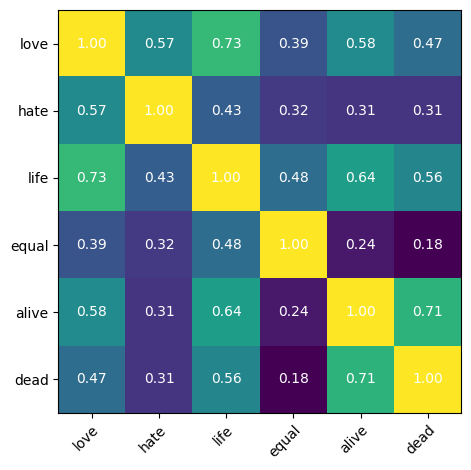

In [226]:
list_of_words = ['love', 'hate', 'life', 'equal', 'alive', 'dead']



### YOUR CODE HERE
def similarity_matrix_plot(list_of_words):
    similarity_matrix = np.zeros((len(list_of_words), len(list_of_words)), dtype=float)
    for i, word1 in enumerate(list_of_words):
        for j, word2 in enumerate(list_of_words):
                similarity_matrix[i][j] = glove_model.similarity(word1, word2)
    plot_similarity_matrix(similarity_matrix, list_of_words)

similarity_matrix_plot(list_of_words)
### YOUR CODE ENDS HERE




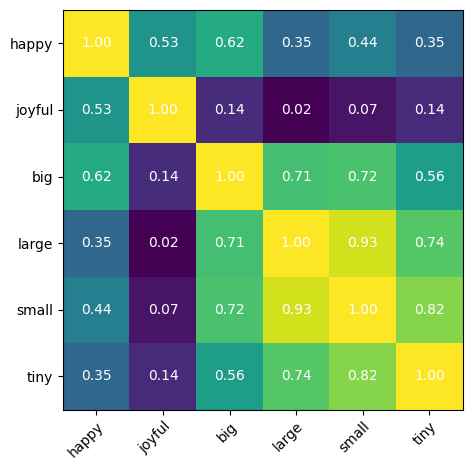

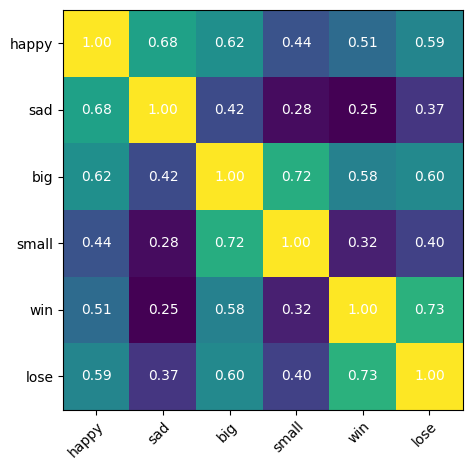

In [228]:
#### YOUR CODE HERE
# Synonyms
list_of_words = ['happy', 'joyful','big', 'large','small','tiny']
similarity_matrix_plot(list_of_words)
# Antonyms 
list_of_words = ['happy', 'sad','big', 'small','win','lose']
similarity_matrix_plot(list_of_words)
### YOUR CODE ENDS HERE

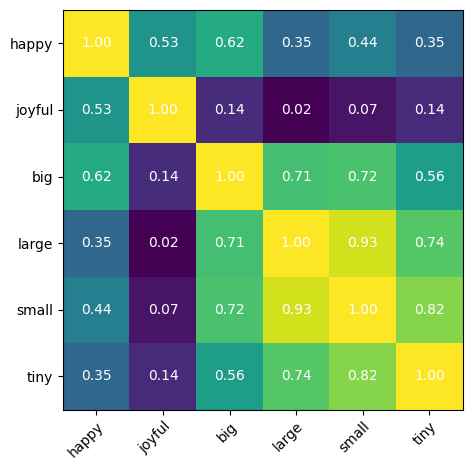

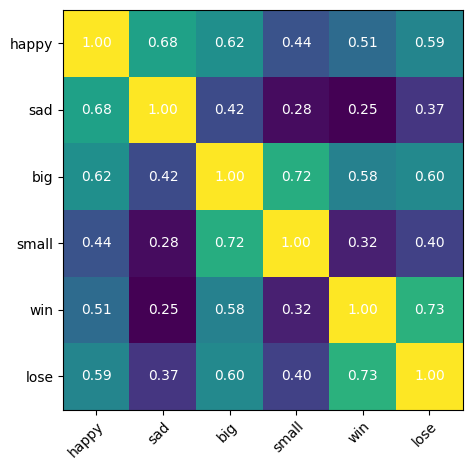

In [229]:
# Synonyms
list_of_words = ['happy', 'joyful','big', 'large','small','tiny']
similarity_matrix_plot(list_of_words)
# Antonyms 
list_of_words = ['happy', 'sad','big', 'small','win','lose']
similarity_matrix_plot(list_of_words)

Although Antonyms have opposing meanings the algorithm still percives them as simillar. This could indicate that the word meaning is not embeded but rather it's usage context. 

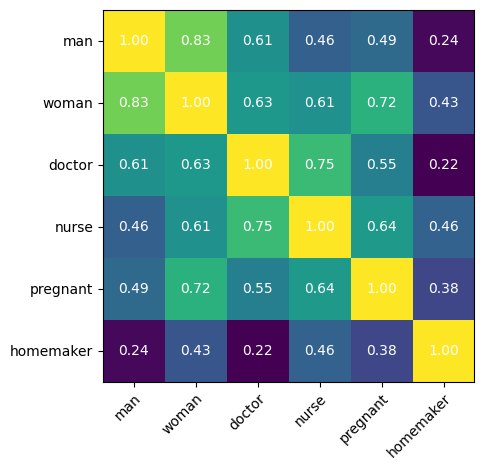

In [230]:
list_of_words = ['man', 'woman', 'doctor', 'nurse', 'pregnant', 'homemaker']
similarity_matrix_plot(list_of_words)

Here we can notice the bias is gender association for words homemaker and nurse, where word women have higher simillarity. We can also observe a logical association of word pregnacy with women rather then man, although based on previous set of words we can assume that it's not logical but rather contextual associaction

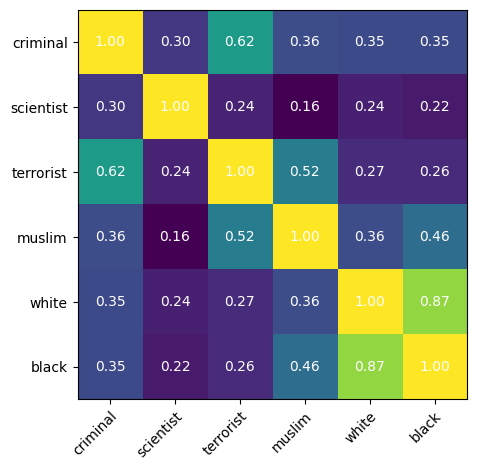

In [231]:
list_of_words = ['criminal', 'scientist', 'terrorist', 'muslim', 'white', 'black']
similarity_matrix_plot(list_of_words)

The similarity matrix shows a strong association between 'black' and 'white'(0.87), likely due to frequent co-occurrence. More concerning is the similarity between 'muslim' and 'terrorist' (0.52), and the low similarity with 'scientist' (0.16), reflecting harmful stereotypes. These biases likely stem from training data sourced from media and online content, which may reinforce negative views of certain groups. This underlines the need for bias-aware evaluation of language models.

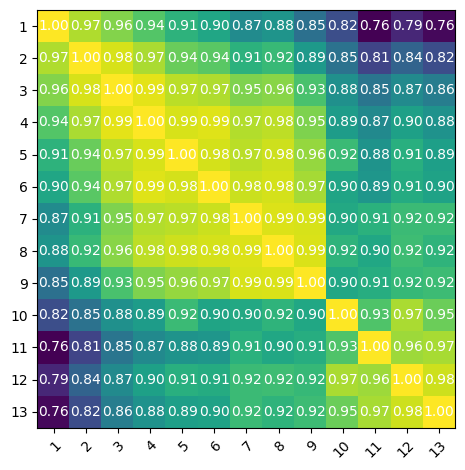

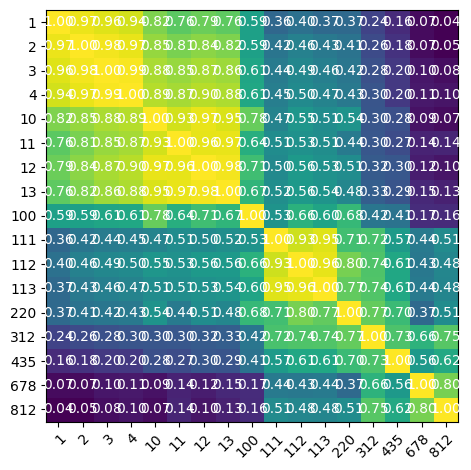

In [178]:
list_of_words = ['1', '2', '3', '4', '5', '6','7', '8', '9', '10', '11', '12','13']
similarity_matrix_plot(list_of_words)
list_of_words = ['1', '2', '3', '4', '10', '11', '12','13','100','111','112','113','220','312','435','678','812']
similarity_matrix_plot(list_of_words)

In the 2 graphs we can observe the pattern of higher simillartity between numbers that are next to each other. The second graph shows how clusters are formed of simillar numbers. The digit count plays smaller role, but still increases simillarity measurement. 

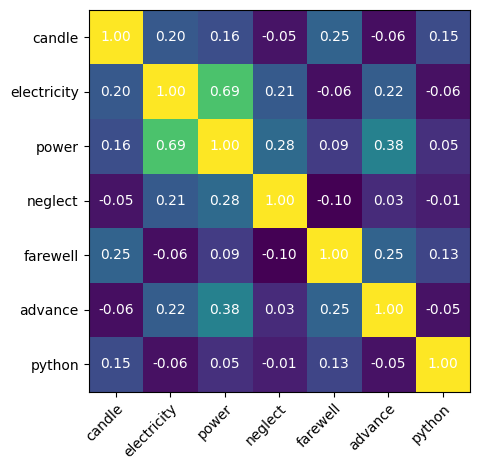

In [179]:
list_of_words = [ 'candle', 'electricity', 'power', 'neglect',  'farewell', 'advance','python']
similarity_matrix_plot(list_of_words)

zelada -0.5071893930435181
outvote -0.5118696093559265
bugeaud -0.5162419676780701
tuiloma -0.5165111422538757
navair -0.5214296579360962
in -0.5755869746208191
lady -0.5856521725654602
from -0.5933263301849365
the -0.5952218770980835
on -0.60857754945755


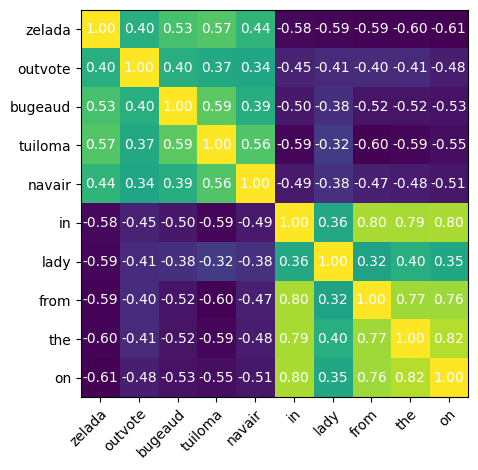

In [180]:
list_of_words=[]
word = "girl"
least_similar = glove_model.most_similar(positive=[word], topn=len(glove_model.index_to_key))[-5:]

for w, sim in least_similar:
    print(w, sim)
    list_of_words.append(w)
word ="zelada"
least_similar = glove_model.most_similar(positive=[word], topn=len(glove_model.index_to_key))[-5:]

for w, sim in least_similar:
    print(w, sim)
    list_of_words.append(w)
similarity_matrix_plot(list_of_words)
    

The sets of vectors with opposite direction and smaller frequency seem to be less simillar to each other compared to the vectors with higher frequency. This could indicate that there are directions that are more dense in vecotrs.

<a name='e11'></a>
### Exercise 11: Other pre-trained word embeddings
(10p) For this exercise, experiment with at least one different word embedding model. You can choose Glove with different dimensions or other pre-trained models. Use the gensim library to download and use the models.
Plot similarity matrices between sets of words you used in the previous exercise and compare the results. Are there noticeable differences? Why (not)?

In [181]:
twitter_model = api.load("glove-twitter-200")

[==================================================] 100.0% 758.5/758.5MB downloaded


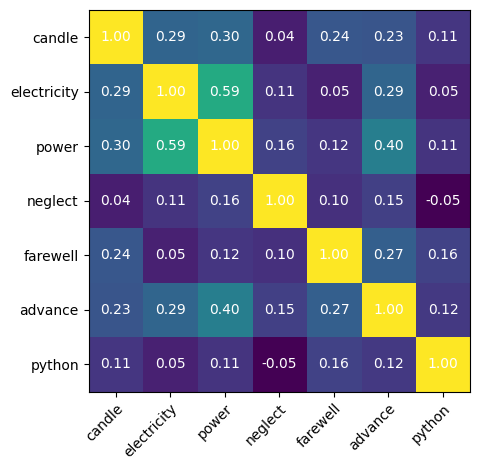

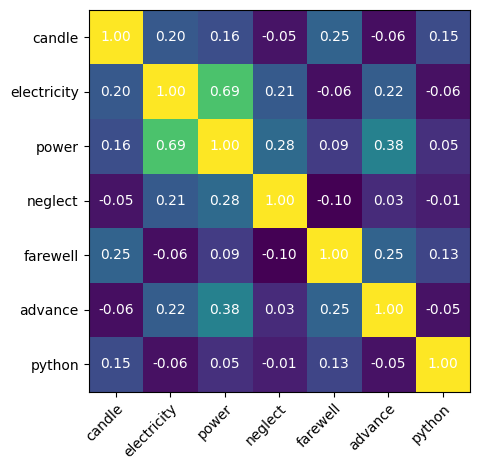

In [182]:
#### YOUR CODE HERE
def twitter_model_similarity_matrix_plot(list_of_words):
    similarity_matrix = np.zeros((len(list_of_words), len(list_of_words)), dtype=float)
    for i, word1 in enumerate(list_of_words):
        for j, word2 in enumerate(list_of_words):
                similarity_matrix[i][j] = twitter_model.similarity(word1, word2)
    plot_similarity_matrix(similarity_matrix, list_of_words)

list_of_words = [ 'candle', 'electricity', 'power', 'neglect',  'farewell', 'advance','python']
twitter_model_similarity_matrix_plot(list_of_words)
similarity_matrix_plot(list_of_words)

### YOUR CODE ENDS HERE

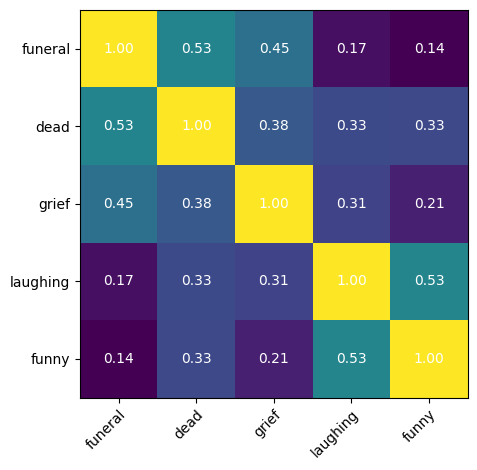

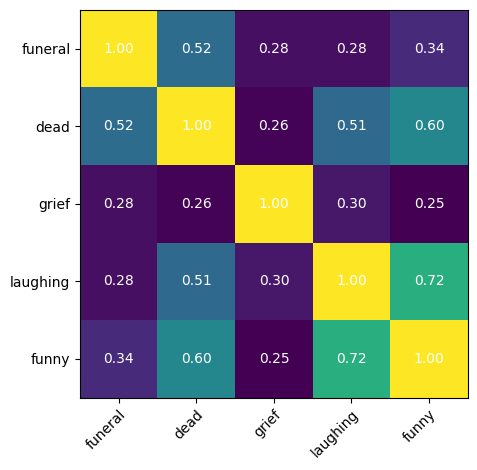

In [183]:
list_of_words = [ 'funeral', 'dead', 'grief', 'laughing', 'funny']
similarity_matrix_plot(list_of_words)
twitter_model_similarity_matrix_plot(list_of_words)

Comment: "glove-twitter-200" was trained on a twitter corpus while "glove-wiki-gigaword-100" was trained on text from wikipedia. Some of the more obvious differences between the two models is how they encode slang words. In wikipedia the word "dead" is primarily used to mean "deceased" but on twitter is can also mean that something is very funny. This appears on the plot as increased similarity of "dead" to "laughing" (0.33 -> 0.51) and decreased similarity of "dead" to "grief" (0.38 -> 0.26).

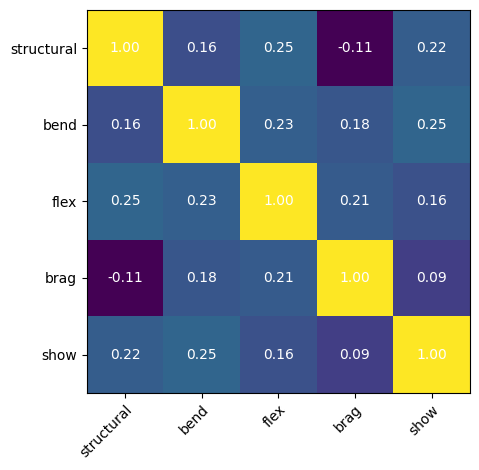

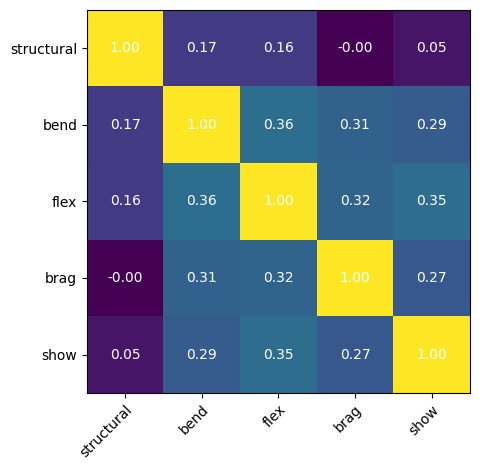

In [184]:
list_of_words = [ 'structural', 'bend', 'flex', 'brag', 'show']
similarity_matrix_plot(list_of_words)
twitter_model_similarity_matrix_plot(list_of_words)

Comment: In the same vein, "flex" in wikipedia is used in the sense of materials bending but on twitter it is more likely to appear meaning to show something off. This appears on the plot as greater similarity of "flex" to "show" and "brag" on the twitter model.

## 5. Sentence Embeddings by Averaging Word Embeddings

Word embeddings are a powerful model for representing words and their meaning (in terms of distributional similarity). As we discussed in class, we can use them in a wide variety of tasks with more complex architectures. Word vectors offer a dense vector for each word. What if we wanted to represent a sentence (or a document) based on word vectors. How can we do that?

In the course, we will see different architectures that take into account the sequence of words (by combining their vectors). A first naive but simple and sometimes (as we are going to see) quite effective approach would be to represent a sentence with an embedding vector that is the average of the word vectors that form the sentence.

So formally, this is what we are aiming for:

$
\text{Sentence_Embedding} = \frac{1}{N} \sum_{i=1}^{N} \text{Word_Embedding}_i
$

where:
* $N$ is the number of words in a sentence
* $\text{Word_Embedding}_i$ is the word vector for the $i$-th in the sentence.

Things to note:
* The embedding vector for the sentence will obviously have the same dimension as the word embedding.
* This representation ignores the word order (like bag-of-words). During the course we will see how we can overcome this limitation by using sequence models.

<a name='e12'></a>
### Exercise 12: Sentence Embedding

(10p) Complete the function below that takes as input the sentence in the form of tokens (so it's a list of words) and calculates the sentence embedding vector. First, we would need to retrieve the word embeddings for each word from our loaded model and then average the vectors.

Note: There can be cases where all tokens from a sentence are out-of-vocabulary words (OOV). Think what to do in this case and make sure to discuss it in the report.

In [185]:
def embed_sentence_word_model(tokens, model):
    """
    Calculates the sentence embedding by averaging the embeddings of the tokens
    Args:
        tokens: a list of words from the sentence
        model: a trained word embeddings model

    Returns: a numpy array of the sentence embedding

    """
    #### YOUR CODE HERE
    #### CAUTION: be sure to cover the case where all tokens are out-of-vocabulary!!!
    
    vectors = []

    for token in tokens:
        if token in model.key_to_index:
            vectors.append(model[token])
    
    if vectors:
        # Average the vectors
        return np.mean(vectors, axis=0)
    else:
        # If OOV-only sentence, we just make a zero vector
        return np.zeros(model.vector_size)


    ### YOUR CODE ENDS HERE

Now we can apply the function to the whole dataset. Here we do it both for the sentence and the compressed version. You should know it by now, but this operation might take some time. The next cells will apply your function to the whole dataset.

In [186]:
def embed_sentence_word_model_dataset(example, model):
    """
    Embeds the sentence and the compressed sentence in the example from the Dataset
    Args:
        example: an example from the Dataset
        model: a trained word embeddings model

    Returns: updated example with 'sentence_embedding' and 'compressed_embedding' columns

    """
    sentence_tokens = example['sentence_tokens']
    clean_compressed = example['clean_compressed']
    compressed_tokens = tokenize(clean_compressed)

    sentence_embedding = embed_sentence_word_model(sentence_tokens, model)
    compressed_embedding = embed_sentence_word_model(compressed_tokens, model)

    example['sentence_embedding'] = sentence_embedding
    example['compressed_embedding'] = compressed_embedding
    return example

In [187]:
test_ds = test_ds.map(embed_sentence_word_model_dataset, fn_kwargs={'model': glove_model})
print(test_ds)

Map:   0%|          | 0/36000 [00:00<?, ? examples/s]

Dataset({
    features: ['set', 'clean_sentence', 'clean_compressed', 'sentence_tokens', 'compressed_tokens', 'sentence_bow', 'compressed_bow', 'sentence_tf-idf', 'sentence_embedding', 'compressed_embedding'],
    num_rows: 36000
})


In [233]:
for i in range(2):
    print(test_ds[i])

{'sentence_bow': array([0., 1., 1., ..., 0., 0., 0.]), 'compressed_bow': array([0., 0., 0., ..., 0., 0., 0.]), 'sentence_tf-idf': array([0.        , 0.00010287, 0.00496252, ..., 0.        , 0.        ,
       0.        ]), 'sentence_embedding': array([-1.81525454e-01,  9.94700100e-03,  1.61984056e-01, -2.23471154e-03,
        4.36664224e-01, -2.29236260e-01, -1.26427084e-01,  3.26183558e-01,
       -2.52375364e-01,  1.51927143e-01,  8.26180875e-02, -1.83121681e-01,
        1.88984387e-02,  2.31597692e-01,  4.94839177e-02, -1.73212111e-01,
        1.80268690e-01, -9.37353596e-02, -3.55223566e-01,  1.38534367e-01,
        1.07820660e-01,  7.11100027e-02,  6.05904698e-01,  5.86428463e-01,
        2.59935737e-01, -2.14321181e-01,  5.38496003e-02,  9.45087820e-02,
        6.25726432e-02, -9.15818810e-02, -3.27353895e-01,  5.40960610e-01,
       -7.35636353e-02,  2.26356357e-01,  2.59346992e-01,  2.25392640e-01,
        1.52372226e-01,  3.28076869e-01, -3.02225232e-01, -2.98725992e-01,
     

Here you can see that the new dataset returned a single numpy array containing all sentence embeddings in our dataset. This is a lot more efficient than returning a list of arrays (which is the default behaviour). Below we check the type and the dimensionality.

We will be using `text` subset from our dataset to not use too much RAM.

In [189]:
sent_embedding = test_ds['sentence_embedding']
compr_embedding = test_ds['compressed_embedding']
print(type(sent_embedding))
print(sent_embedding.shape)
print(type(compr_embedding))
print(compr_embedding.shape)

<class 'numpy.ndarray'>
(36000, 100)
<class 'numpy.ndarray'>
(36000, 100)


Next we try the condensed representation based on a simple query. Feel free to try different queries with different words. What happens if we have OOV words in a query?

In [190]:
query = 'fox and deer'
print(query)

query_embedding = embed_text(query, clean, tokenize, lambda x: embed_sentence_word_model(x, glove_model))
print(query_embedding.shape)
print(query_embedding)

fox and deer
(100,)
[-7.9574332e-02 -3.4770331e-01  1.7729366e-01 -6.0485005e-01
  3.0022332e-02 -3.1933334e-01 -3.3017006e-02  3.8080001e-01
 -9.5549993e-02 -6.8293667e-01 -2.5135002e-01 -2.6160267e-01
  5.4243332e-01  4.8967004e-02  6.4244002e-01  1.4520667e-01
  1.6598998e-01  2.1143766e-01 -2.9778001e-01  3.7910333e-01
 -2.5491999e-02  3.0857334e-01  4.4262299e-01 -4.8366687e-03
  5.1693004e-01  6.1506337e-01 -1.6002001e-01 -1.9082667e-01
 -4.2462167e-01 -1.7103335e-02  9.1679998e-02  5.4518598e-01
  2.2566617e-03  4.1771331e-01  2.9497001e-01  2.8101999e-01
 -2.5762668e-02  2.4963665e-01  3.6236334e-01  2.3719667e-01
 -2.1890998e-01 -2.1570998e-01 -4.9093699e-01  1.8930303e-01
 -2.2870134e-01  2.5945336e-02  2.1237333e-01 -3.5905001e-01
  1.7600060e-03 -3.3630332e-01 -6.9356328e-01 -1.8233334e-01
  9.2886640e-03  9.2804670e-01 -2.8199133e-01 -1.7956600e+00
 -1.0166732e-01  2.3830002e-02  7.7983665e-01  2.9350668e-01
 -4.9146999e-02  7.9245996e-01  3.5156965e-01  2.4036676e-02
  1.

In [191]:
query = 'aburacudabura'
print(query)

query_embedding = embed_text(query, clean, tokenize, lambda x: embed_sentence_word_model(x, glove_model))
print(query_embedding.shape)
print(query_embedding)

# OOV word results in a 0-vector as intended

aburacudabura
(100,)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


<a name='e13'></a>
### Exercise 13: Analyze sentence embeddings
- (5p) Calculate similarity between the word embeddings representations of the selected queries and the dataset sentences.
- (5p) Analyze the search results. Does the search work as expected? Discuss the results.
- (5p) Compare the results with the ones you got with the bag-of-words and TF-IDF representation. Discuss the differences and similarities.

In [235]:
### YOUR CODE HERE

query = 'many buildings destroyed'
print(query)

query_embedding = embed_text(query, clean, tokenize, lambda x: embed_sentence_word_model(x, glove_model))
print(query_embedding[:10])
print(query_embedding.shape)


sentence_embeddings = np.array(test_ds['sentence_embedding'])

# evaluate embedding cosine similarities for entire test corpus
similarities = []
for i in sentence_embeddings:
    similarities.append(cosine_similarity(query_embedding, i))
    
similarities = np.array(similarities)


top_k = similarities.argsort()[-5:][::-1]
for idx in top_k:
    original = test_ds['set'][idx][0]
    compressed = test_ds['clean_compressed'][idx]
    sim = similarities[idx]
    print(f"[{sim:.4f}] {original}\n  ↳ {compressed}\n")


### YOUR CODE ENDS HERE

many buildings destroyed
[-0.10629067  0.61249    -0.30977336  0.12162668 -0.14808533  0.42420664
 -0.26978332  0.12674667  0.59576136  0.5671533 ]
(100,)
[0.8341] A tornado destroyed dozens of homes and businesses in this small Mississippi community early Thursday, injuring 20 people and flattening a church.
  ↳ tornadoes destroy dozens

[0.8284] Two four-story Brooklyn apartment buildings were evacuated early Wednesday after construction next door undermined their stability.
  ↳ brooklyn apartment building evacuated

[0.8270] An electrical fire destroyed a downtown bakery and pastry shop early Saturday, leaving residents of five adjoining apartments temporarily homeless.
  ↳ fire destroys downtown bakery

[0.8235] An overnight fire has destroyed a vacant home in Newport and caused thousands of dollars in damages to neighboring buildings.
  ↳ overnight fire destroys vacant home in newport

[0.8214] Techiman has experienced five fire outbreaks within the past two weeks and the fires de

##### Comparing to bag-of-words and TF-IDF

Sentence embeddings would be seem superior to bag-of-words and TF-IDF as they would be able to capture the semantic similarity of related words. For example the word embedding for "woman" would probably be similar to word embedding for "lady". That would hopefully allow the system to interpret the semantic content of words as opposed to treating them discretely.

I attempted to find the result "A woman was abducted in a grocery store parking lot last night in Crystal, police say."

For the query "A lady was kidnapped in a supermarket parking lot", both the bag-of-words and TF-IDF methods failed to retrieve the original sentence while the sentence embedding system succeeded. The same happened for "lady kidnapped shop parking lot".

In [193]:
compare_bow_tfidf_similarities('A lady was kidnapped in a supermarket parking lot')


---------- Query: A lady was kidnapped in a supermarket parking lot ----------

---------- BoW Top-3 Results ----------
A boy, 7, was killed in a gun store parking lot in Pennsylvania.
   # BoW similarity score: 0.5785 |  TF-IDF score at same index: 0.3578
A driver was killed when a car left a road in Cambridgeshire and hit a concrete bollard.
   # BoW similarity score: 0.5698 |  TF-IDF score at same index: 0.0372
The driver of a vehicle was killed in a collision with a train at a gated crossing Tuesday morning in Ephrata.
   # BoW similarity score: 0.5688 |  TF-IDF score at same index: 0.0370

---------- TF-IDF Top-3 Results ----------
A boy, 7, was killed in a gun store parking lot in Pennsylvania.
   # TF-IDF similarity score: 0.3578 | BoW score at same index: 0.5785
A man was found dead in the parking lot at an apartment complex on the Northside early Tuesday morning.
   # TF-IDF similarity score: 0.3540 | BoW score at same index: 0.3948
``Third Front is a parking lot for many pol

In [194]:
query = 'A lady was kidnapped in a supermarket parking lot'
query_embedding = embed_text(query, clean, tokenize, lambda x: embed_sentence_word_model(x, glove_model))

similarities = []
for i in sentence_embeddings:
    similarities.append(cosine_similarity(query_embedding, i))
    
similarities = np.array(similarities)

top_k = similarities.argsort()[-5:][::-1]
for idx in top_k:
    original = test_ds['set'][idx][0]
    compressed = test_ds['clean_compressed'][idx]
    sim = similarities[idx]
    print(f"[{sim:.4f}] {original}\n  ↳ {compressed}\n")

[0.9573] A Gastonia woman was arrested over the weekend, accused of leaving two children alone in a hot car while she shopped inside a Target store.
  ↳ gastonia woman arrested after leaving children alone in hot car

[0.9557] A woman was abducted at gunpoint Monday night in the parking lot of a Pearland strip shopping center.
  ↳ woman abducted at gunpoint near pearland center

[0.9555] A suspect forced a store clerk into a restroom and robbed a Winston-Salem business early Thursday morning.
  ↳ suspect forces clerk into restroom , robs business

[0.9545] A man found in a parking lot after a burglary call at a Powell County pawn shop early Wednesday morning has died.
  ↳ man found in parking lot dies

[0.9543] A homeless man reportedly threw a shoe at a beehive near a Home Depot store and the bees were attacking ``everyone that walks by,'' a caller said.
  ↳ man reportedly throws shoe at beehive



Interestingly, sentence embeddings are not always superior to TF-IDF. For example, for "woman abducted" sentence embedding system does not retrieve the original sentence but both BoW and TF-IDF do. BoW and TF-IDF manage it only because the exact same words are used in the original sentence. 

In the real world, when looking for information about something you are unlikely to use the exact words used in a helpful document. You may express yourself with synonyms or slightly different but related terms. However, in this datset, the compressed sentence often has the same key nouns and verbs as the full sentence. 

For example, for "A woman was abducted in a grocery store parking lot last night in Crystal, police say." the sentence has keywords like "woman", "abducted", "grocery". However, the compressed version "woman abducted in grocery store parking lot in crystal" has the very same keywords "woman", "abducted", "grocery". Thus, these exact repeating terms probably make BoW and TF-IDF work better here than they would 'in the wild'.

In [195]:
compare_bow_tfidf_similarities('woman abducted')


---------- Query: woman abducted ----------

---------- BoW Top-3 Results ----------
An elderly French woman was kidnapped close to the Kenyan tourist resort of Lamu, near where a British woman was abducted and her husband killed last month, police and diplomatic sources said on Saturday.
   # BoW similarity score: 0.3198 |  TF-IDF score at same index: 0.3936
A woman was abducted at gunpoint Monday night in the parking lot of a Pearland strip shopping center.
   # BoW similarity score: 0.3162 |  TF-IDF score at same index: 0.4662
An Alexandria man is accused of grabbing a woman's buttocks and making sexually explicit comments to another woman, authorities reported.
   # BoW similarity score: 0.3086 |  TF-IDF score at same index: 0.2121

---------- TF-IDF Top-3 Results ----------
A woman was abducted at gunpoint Monday night in the parking lot of a Pearland strip shopping center.
   # TF-IDF similarity score: 0.4662 | BoW score at same index: 0.3162
A 25-year old youth was abducted and

In [196]:
query = 'woman abducted'
query_embedding = embed_text(query, clean, tokenize, lambda x: embed_sentence_word_model(x, glove_model))

similarities = []
for i in sentence_embeddings:
    similarities.append(cosine_similarity(query_embedding, i))
    
similarities = np.array(similarities)

top_k = similarities.argsort()[-5:][::-1]
for idx in top_k:
    original = test_ds['set'][idx][0]
    compressed = test_ds['clean_compressed'][idx]
    sim = similarities[idx]
    print(f"[{sim:.4f}] {original}\n  ↳ {compressed}\n")

[0.7353] A 26-year-old woman was arrested Wednesday night after she allegedly stabbed her live-in boyfriend with a steak knife.
  ↳ woman arrested for allegedly stabbing boyfriend

[0.7238] A 28-year-old Tacoma man wanted for assaulting his pregnant girlfriend was arrested Wednesday night.
  ↳ tacoma man wanted for assaulting pregnant girlfriend arrested

[0.7218] A 39-year-old Billings woman is accused of assaulting her pregnant daughter in front of her 4-year-old grandchild.
  ↳ billings woman accused of assaulting pregnant daughter

[0.7180] Malaysian police say a 3-year-old girl was killed in a suspected exorcism ritual by her parents and other relatives.
  ↳ malaysian girl killed in suspected exorcism ritual

[0.7157] A 19-year-old girl was allegedly abducted and gangraped by two youths here, police said.
  ↳ girl abducted , gangraped



A limitation of embedding-based search is that queries with out-of-vocabulary (OOV) words result in zero vectors but bag-of-words and TF-IDF methods have similar limitations as they would ignore OOV words as well.

## 6. Evaluating Retrieval

In this last section we will try to evaluate how good our sentence retrieval system is. To keep the computational resources manageable, we will use the test set for that as its size is more manageable.

Recall from the lecture in IR that there are several metrics to evaluate retrieval performance by taking into account the relevance of the retrieved results to the query. We will use Recall@K here (for more metrics and more details refer to the lecture slides and the textbooks).

RRecall@K is a metric used to measure the effectiveness of a search system in retrieving relevant documents within the top $K$ retrieved documents. It calculates the proportion of relevant documents retrieved within the top-$K$ results, compared to the total number of relevant documents in the collection.

$
\text{Recall@K} = \frac{\text{Number of relevant documents retrieved in the top }-K}{\text{Total number of relevant documents}}
$

In our case, we have a sentence, and it's compressed version. To test our system, we will treat compressed sentences as the queries. Each query will have only a single relevant sentence - the corresponding uncompressed sentence.

Therefore, for the calculation of Recall@K we will take into account whether the correct retrieved result is contained within the first $K$ retrieved results. For example, if for a query (i.e. a compressed sentence) we retrieve 10 results and within these we see the relevant one (i.e. the full sentence), then Recall@10 = 1.

<a name='e14'></a>
### Exercise 14: Cosine similarity between two sets of vectors

(3p) In this exercise you will revisit your implementation of the cosine similarity. Generalize it so that it can accept two arrays containing two sets of vectors (first one containing $M$ vectors and the second one $N$ vectors). Compute the cosine similarity between each pair of vectors coming from the two sets. The result should be an array of size $M x N$.

Once again, try to write an efficient code. This means no loops. Remember the relation between matrix multiplication and dot product. (Depending on your implementation of the previous function calculating cosine similarity, this one can be almost the same)

In [197]:
def cosine_similarity_m_to_n(vectors, other_vectors):
    """
    Calculates the cosine similarity between a multiple vectors and other vectors.
    Args:
        vectors: a numpy array representing M number of vectors of D dimensions (of the size MxD)
        other_vectors: a 2D numpy array representing other vectors (of the size NxD, where N is the number of vectors and D is their dimension)

    Returns: a numpy array of cosine similarity between all the vectors and all the other vectors

    """

    #### YOUR CODE HERE

    # Matrix multiplication of 2 matrices is equivalent to taking the dot-product between the rows and columns of the two. So first we do:
    dot_products = vectors @ other_vectors.T  # (M x N)

    # Normalizing
    norm_vectors = np.linalg.norm(vectors, axis=1, keepdims=True)
    norm_others = np.linalg.norm(other_vectors, axis=1, keepdims=True).T

    # 1e-10 helps with invalid values
    return dot_products / (norm_vectors * norm_others + 1e-10)

    ### YOUR CODE ENDS HERE

The following function will use your implementation to calculate Recall@K based on the similarity matrix.

In [198]:
def calculate_recall(queries, sentences, k, batch_size=100):
    """
    Calculates recall@k given the embeddings of the queries and sentences.
    Assumes that only a single sentence with the same index as query is relevant.
    Batching is implemented to avoid high memory usage.
    Args:
        queries: a numpy array with the embeddings of N queries
        sentences: a numpy array with the embeddings of N sentences available for retrieval
        k: number of top results to search for the relevant sentence
        batch_size: number of queries to process at a time

    Returns: calculated recall@k

    """
    n_queries = queries.shape[0]
    correct = np.zeros(n_queries, dtype=bool)

    with tqdm.tqdm(total=n_queries) as pbar:
        for batch_start in range(0, n_queries, batch_size):
            batch_end = min(batch_start + batch_size, n_queries)
            queries_batch = queries[batch_start:batch_end]
            batch_similarity = cosine_similarity_m_to_n(queries_batch, sentences)

            for i, similarity_row in enumerate(batch_similarity):
                query_index = batch_start + i
                top_k = top_k_indices(similarity_row, k=k, sorted=False)

                if query_index in top_k:
                    correct[query_index] = True

                pbar.update(1)

    recall = np.sum(correct) / n_queries
    return recall

You can use it like so:

In [199]:
recall_at_1 = calculate_recall(compr_embedding, sent_embedding, k=1, batch_size=1000)
print(f'\n{recall_at_1 * 100:.2f}%')

100%|███████████████████████████████████| 36000/36000 [00:15<00:00, 2357.34it/s]


49.78%


<a name='e15'></a>
### Exercise 15: Evaluating retrieval methods

(10p) Calculate recall for different values of $K$ for all methods:
- BOW,
- TF-IDF,
- Pre-trained embeddings.

Discuss the results.
Comment on how recall changes based on the value of $K$. Are the results expected or surprising?

In [200]:
# freeing up memory
del glove_model
del twitter_model

In [201]:
# Bag of Words

compressed_bow_int16 = np.array([np.array(row, dtype=np.int16) for row in test_ds['compressed_bow'][:5000]])
sentence_bow_int16 = np.array([np.array(row, dtype=np.int16) for row in test_ds['sentence_bow'][:5000]])

bow_recall_1 = calculate_recall(compressed_bow_int16, sentence_bow_int16, k=1)
bow_recall_3 = calculate_recall(compressed_bow_int16, sentence_bow_int16, k=3)
bow_recall_5 = calculate_recall(compressed_bow_int16, sentence_bow_int16, k=5)

100%|███████████████████████████████████████| 5000/5000 [02:06<00:00, 39.46it/s]


In [202]:
# TF-IDF
tfidf_queries = np.array([calculate_tf_idf_single(bow) for bow in compressed_bow_int16])
tfidf_sentences = np.array([calculate_tf_idf_single(bow) for bow in sentence_bow_int16])

tfidf_recall_1 = calculate_recall(tfidf_queries, tfidf_sentences, k=1)
tfidf_recall_3 = calculate_recall(tfidf_queries, tfidf_sentences, k=3)
tfidf_recall_5 = calculate_recall(tfidf_queries, tfidf_sentences, k=5)

100%|██████████████████████████████████████| 5000/5000 [00:08<00:00, 574.97it/s]


In [203]:
# Word Embeddings
embedding_recall_1 = calculate_recall(compr_embedding[:5000], sent_embedding[:5000], k=1)
embedding_recall_3 = calculate_recall(compr_embedding[:5000], sent_embedding[:5000], k=3)
embedding_recall_5 = calculate_recall(compr_embedding[:5000], sent_embedding[:5000], k=5)

100%|████████████████████████████████████| 5000/5000 [00:00<00:00, 10108.73it/s]


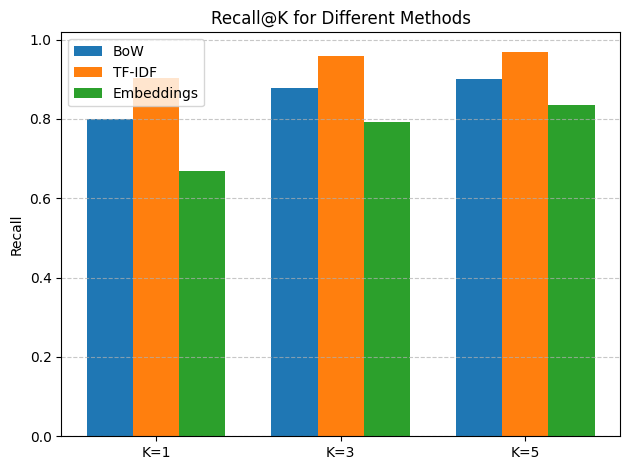

In [204]:
# Bar chart with different K values for each method

k_labels = ['K=1', 'K=3', 'K=5']
x = np.arange(len(k_labels))  # K positions
width = 0.25

fig, ax = plt.subplots()

rects1 = ax.bar(x - width, [bow_recall_1, bow_recall_3, bow_recall_5], width, label='BoW')

rects2 = ax.bar(x, [tfidf_recall_1, tfidf_recall_3, tfidf_recall_5], width, label='TF-IDF')

rects3 = ax.bar(x + width, [embedding_recall_1, embedding_recall_3, embedding_recall_5], width, label='Embeddings')

ax.set_ylabel('Recall')
ax.set_title('Recall@K for Different Methods')
ax.set_xticks(x)
ax.set_xticklabels(k_labels)
ax.legend()

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
fig.tight_layout()
plt.show()


We used a subset of the test set because of how slow the computation was going. 

Increasing $K$ increases recall which is exactly what we would expect to see as it essentially gives the system more opportunities to be correct. TF-IDF demonstrates the best performance of the three methods. 

<a name='e16'></a>
### Exercise 16: Improving retrieval

(10p) Imagine that you work at a company and are tasked with delivering the best retrieval method. Select the most promising one and try to improve the scores (e.g. by changing the vocab size, loading different model, etc.).
Discuss the results you achieve, even if you didn't manage to improve the scores.

In business or production settings, the most effective and systems today generally use neural network based document embedders. This counts as an improvement to the sentence embeddings we derived from averaging word embeddings for each token in the sentence. Instead, the network produces embeddings for a sentence or document directly. These kinds of systems can produce the most useful embeddings because compared to bag-of-words and TF-IDF appoaches the embeddings are learned....

I looked at the best performing open-source systems of this kind at:
https://huggingface.co/spaces/mteb/leaderboard

The model I picked is based on the widespread transformer architecture, the same architecture that is used in generative AI. It outputs a 384 dimensional embedding for a given string of text.The resulting recall@k for k=1 is 0.98 essentially solving the particular task.

In [236]:
 ! pip install transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 14.8 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 MB 14.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 14.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 4.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [237]:
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import trange

tokenizer = AutoTokenizer.from_pretrained('BAAI/bge-small-en')
model = AutoModel.from_pretrained('BAAI/bge-small-en')
model.eval()  # Disable dropout etc.

clean_sentences = test_ds['clean_sentence'][:5000]
compressed_sentences = test_ds['clean_compressed'][:5000]

# Function to get embeddings in small batches
def get_embeddings(sentences, batch_size=100):
    all_embeddings = []

    for i in trange(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        
        encoded_input = tokenizer(batch, padding=True, truncation=True, return_tensors='pt')
        
        with torch.no_grad():
            model_output = model(**encoded_input)
            embeddings = model_output[0][:, 0]  # CLS token
            embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
        
        all_embeddings.append(embeddings) 

        # Free up memory
        del encoded_input
        del model_output
        del embeddings
        torch.cuda.empty_cache() 

    return torch.cat(all_embeddings, dim=0)

# Compute sentence embeddings
clean_sentence_embeddings = get_embeddings(clean_sentences, batch_size=100)
compressed_sentence_embeddings = get_embeddings(compressed_sentences, batch_size=100)


tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

100%|███████████████████████████████████████████| 50/50 [00:05<00:00,  8.65it/s]


In [238]:
calculate_recall(compressed_sentence_embeddings, clean_sentence_embeddings, 1, batch_size=100)

100%|████████████████████████████████████| 5000/5000 [00:00<00:00, 16445.89it/s]


0.9746

I decide to adapt 'calculate_recall' to check the sentence pairs where bge failed.

In [239]:
def find_missed_indices(queries, sentences, k, batch_size=100):

    n_queries = queries.shape[0]
    missed_indices = []

    with tqdm.tqdm(total=n_queries) as pbar:
        for batch_start in range(0, n_queries, batch_size):
            batch_end = min(batch_start + batch_size, n_queries)
            queries_batch = queries[batch_start:batch_end]
            batch_similarity = cosine_similarity_m_to_n(queries_batch, sentences)

            for i, similarity_row in enumerate(batch_similarity):
                query_index = batch_start + i
                top_k = top_k_indices(similarity_row, k=k, sorted=False)

                if query_index not in top_k:
                    missed_indices.append(query_index)

                pbar.update(1)

    return missed_indices


In [240]:
find_missed_indices(compressed_sentence_embeddings[:1000], clean_sentence_embeddings[:1000], 1, batch_size=100)

100%|████████████████████████████████████| 1000/1000 [00:00<00:00, 44760.73it/s]


[86, 95, 156, 214, 478, 569, 613, 645, 700, 825, 847, 934, 969]

In [241]:
for i in [413, 473, 537, 757, 796, 871, 910, 969]:
    print(test_ds['set'][i])
    print("#######################################")

["Rock and roll legend Alice Cooper joins the Tigers' broadcast booth after throwing out the ceremonial first pitch before the game", 'Alice Cooper joins the booth']
#######################################
['And for all the obvious imperfections of our governmental system, the political bottom line in this country is that what the Jamaican people want, the Jamaican people get.', 'What the people want, they get']
#######################################
['Consul-General of Turkey in Karachi Fethi said on Wednesday that Pakistan was not made of bullets and guns alone but has a glorious civilisation to be cherished by the people of the country.', 'Pakistan is not made of bullets and guns alone:']
#######################################
["A conference in Jericho and the Jordan Valley has been told that the water situation in Palestine is ``catastrophic''.", "Conference told that water situation in Palestine is ``catastrophic''"]
#######################################
['Maple Valley-based R

Looking at the failure cases, it is clear that most of them the compressed sentence is not a valid or sufficient for even a human to retrieve the corresponding full sentence. So these cases don't really represent any failure of the model as much as a failure of the dataset.